# Revision Analyses

In [80]:
# imports
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
import pymorphy3
import re
from adjustText import adjust_text
import io, contextlib

np.random.seed(42)

In [81]:
# load data, assign periods
data = pd.read_csv("data/novels_titles_processed.csv")
data = data[data["year_begin"] != "19??"]
data["year_begin"] = data["year_begin"].astype("int64")
data = data[data["year_begin"] <= 1917]
data = data.sort_values("year_begin").reset_index(drop=True)

with open("data/sberbank-ai-sbert_large_nlu_ru_mp.pickle", "rb") as f:
    title_to_embedding = pickle.load(f)

def assign_period(year):
    if 1760 <= year <= 1779: return "1760-1779"
    elif 1780 <= year <= 1799: return "1780-1799"
    elif 1800 <= year <= 1829: return "1800-1829"
    else: return (year // 10) * 10

data["period"] = data["year_begin"].apply(assign_period)
period_order = ["1760-1779", "1780-1799", "1800-1829", 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910]

print(f"novels: {len(data)}, embeddings: {len(title_to_embedding)}")
print(data["period"].value_counts().reindex(period_order))

novels: 2029, embeddings: 1973
period
1760-1779     12
1780-1799     38
1800-1829     21
1830         161
1840         101
1850          90
1860         114
1870         174
1880         355
1890         444
1900         261
1910         258
Name: count, dtype: int64


## Reviewer 1

### Corpus imbalance and stabilization

#### Novels per period

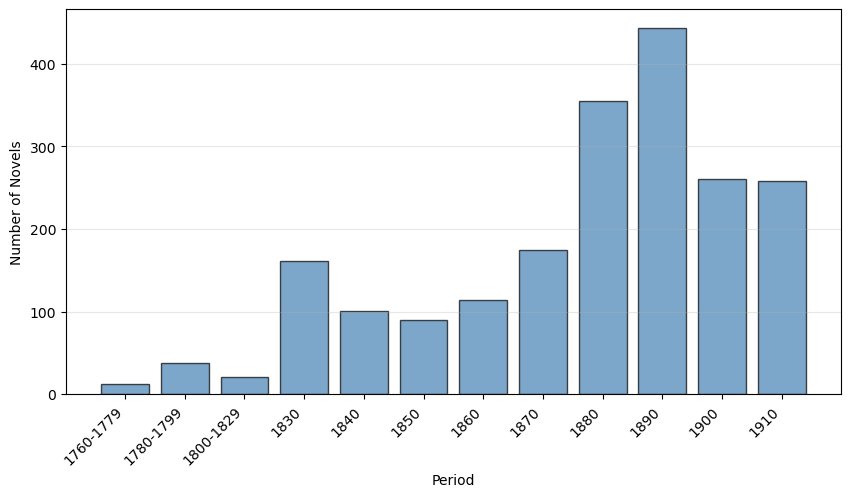

In [82]:
# bar chart: novels per period
period_counts = data["period"].value_counts().reindex(period_order)

plt.figure(figsize=(10, 5))
plt.bar(range(len(period_order)), period_counts.values, color="steelblue", edgecolor="black", alpha=0.7)
plt.xticks(range(len(period_order)), [str(p) for p in period_order], rotation=45, ha="right")
plt.xlabel("Period")
plt.ylabel("Number of Novels")
plt.grid(True, alpha=0.3, axis="y")
plt.savefig("figures/novels_per_period.png", dpi=300, bbox_inches="tight")
plt.show()

#### Downsampling robustness check

In [83]:
# group embeddings by period
period_embeddings = {}
for _, row in data.iterrows():
    title = row["title"]
    period = row["period"]
    if title not in title_to_embedding:
        continue
    if period not in period_embeddings:
        period_embeddings[period] = []
    period_embeddings[period].append(title_to_embedding[title])

period_embeddings = {p: np.vstack(v) for p, v in period_embeddings.items()}
periods_valid = [p for p in period_order if p in period_embeddings]

In [84]:
# downsampling: 1000 iterations, n=min per period
min_n = min(len(v) for v in period_embeddings.values())
n_iter = 1000
print(f"downsampling to n={min_n} per period, {n_iter} iterations")

accumulated = np.zeros((len(periods_valid), len(periods_valid)))
for _ in range(n_iter):
    sampled_means = []
    for p in periods_valid:
        embs = period_embeddings[p]
        idx = np.random.choice(len(embs), size=min_n, replace=False)
        sampled_means.append(embs[idx].mean(axis=0))
    accumulated += cosine_similarity(np.vstack(sampled_means))

downsampled_matrix = accumulated / n_iter
full_means = np.vstack([period_embeddings[p].mean(axis=0) for p in periods_valid])
full_matrix = cosine_similarity(full_means)

downsampling to n=12 per period, 1000 iterations


In [85]:
# print full and downsampled similarity matrices
print("FULL MATRIX")
print(pd.DataFrame(full_matrix, index=periods_valid, columns=periods_valid).round(3))
print()
print("DOWNSAMPLED MATRIX")
print(pd.DataFrame(downsampled_matrix, index=periods_valid, columns=periods_valid).round(3))

FULL MATRIX
           1760-1779  1780-1799  1800-1829   1830   1840   1850   1860   1870  \
1760-1779      1.000      0.946      0.929  0.909  0.870  0.821  0.794  0.797   
1780-1799      0.946      1.000      0.937  0.933  0.915  0.869  0.841  0.855   
1800-1829      0.929      0.937      1.000  0.967  0.934  0.886  0.855  0.865   
1830           0.909      0.933      0.967  1.000  0.976  0.944  0.915  0.929   
1840           0.870      0.915      0.934  0.976  1.000  0.976  0.955  0.966   
1850           0.821      0.869      0.886  0.944  0.976  1.000  0.981  0.982   
1860           0.794      0.841      0.855  0.915  0.955  0.981  1.000  0.990   
1870           0.797      0.855      0.865  0.929  0.966  0.982  0.990  1.000   
1880           0.817      0.870      0.889  0.950  0.978  0.987  0.982  0.989   
1890           0.813      0.868      0.881  0.940  0.971  0.986  0.984  0.990   
1900           0.815      0.872      0.881  0.943  0.973  0.980  0.978  0.990   
1910           0

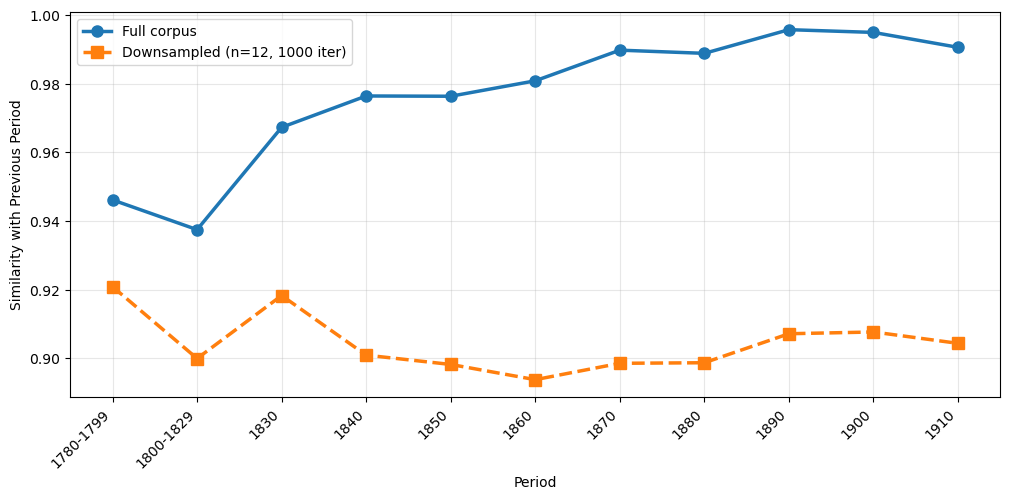

In [86]:
# similarity with previous period: full vs downsampled
full_diag = np.diag(full_matrix, k=-1)
down_diag = np.diag(downsampled_matrix, k=-1)
x_labels = [str(p) for p in periods_valid[1:]]

plt.figure(figsize=(12, 5))
plt.plot(x_labels, full_diag, marker="o", label="Full corpus", linewidth=2.5, markersize=8)
plt.plot(x_labels, down_diag, marker="s", linestyle="--",
         label=f"Downsampled (n={min_n}, {n_iter} iter)", linewidth=2.5, markersize=8)
plt.xlabel("Period")
plt.ylabel("Similarity with Previous Period")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("figures/similarity_dynamics_downsampled.png", dpi=300, bbox_inches="tight")
plt.show()

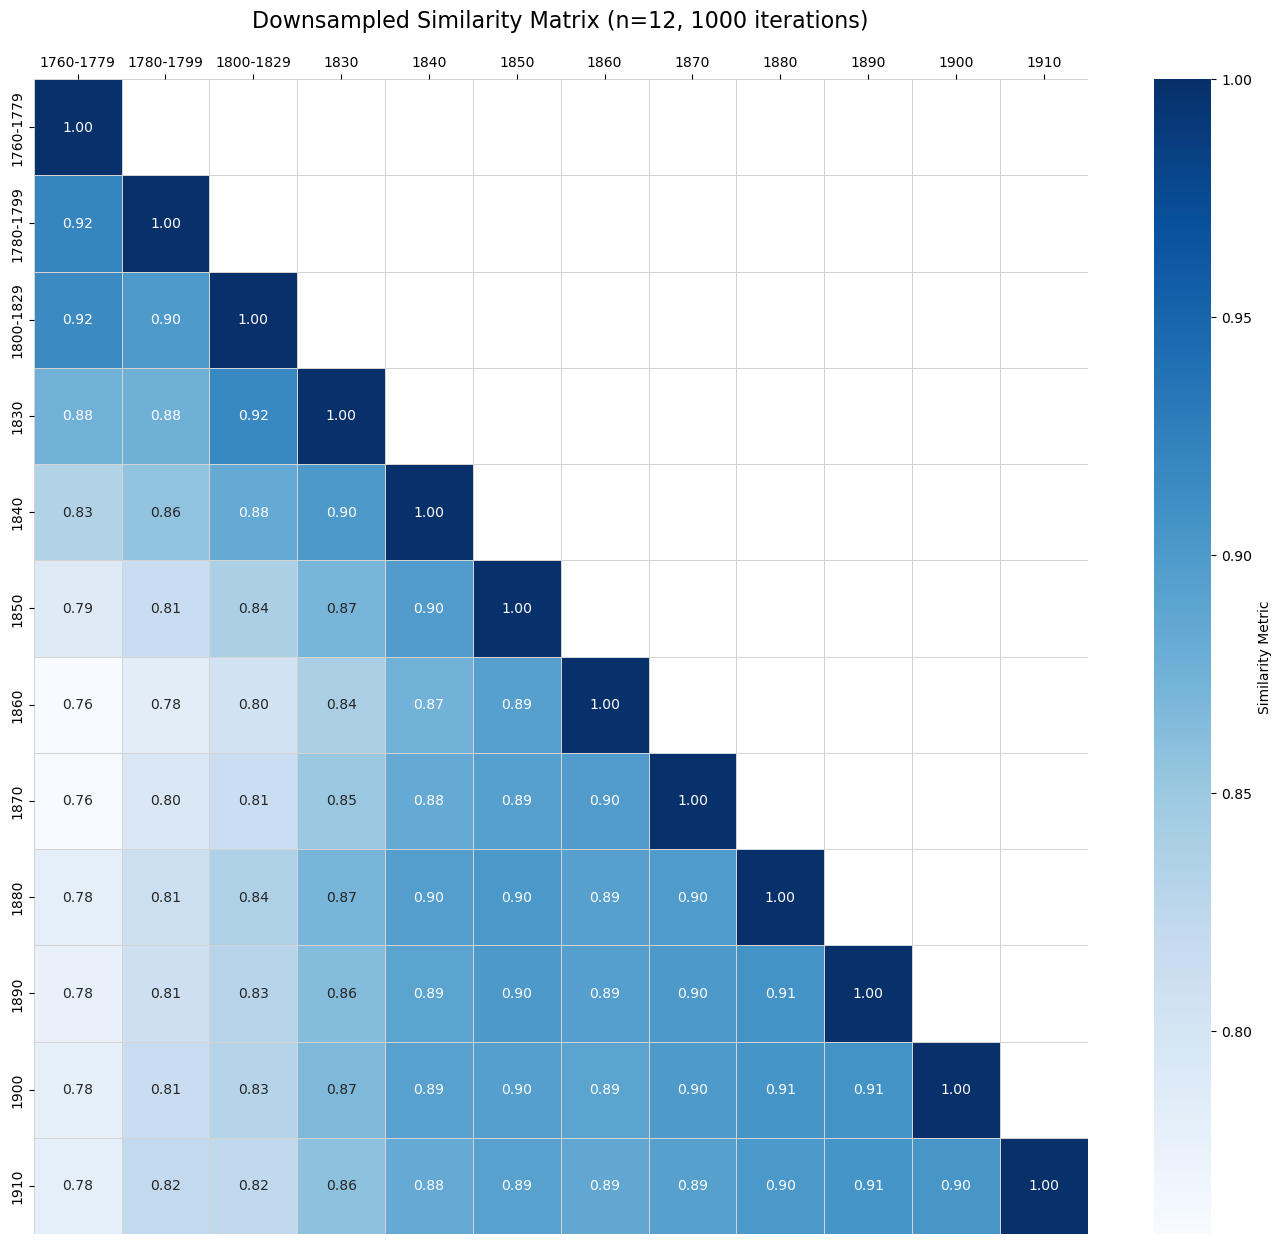

In [87]:
# heatmap: downsampled similarity matrix
mask = np.triu(np.ones_like(downsampled_matrix, dtype=bool), k=1)
plt.figure(figsize=(17, 15))
ax = sns.heatmap(downsampled_matrix, xticklabels=[str(p) for p in periods_valid],
                 yticklabels=[str(p) for p in periods_valid],
                 cmap="Blues", annot=True, fmt=".2f", mask=mask,
                 cbar_kws={"label": "Similarity Metric"}, linewidths=.5, linecolor="lightgray")
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()
plt.title(f"Downsampled Similarity Matrix (n={min_n}, {n_iter} iterations)", fontsize=16, pad=20)
plt.savefig("figures/similarity_matrix_downsampled.png", dpi=300, bbox_inches="tight")
plt.show()

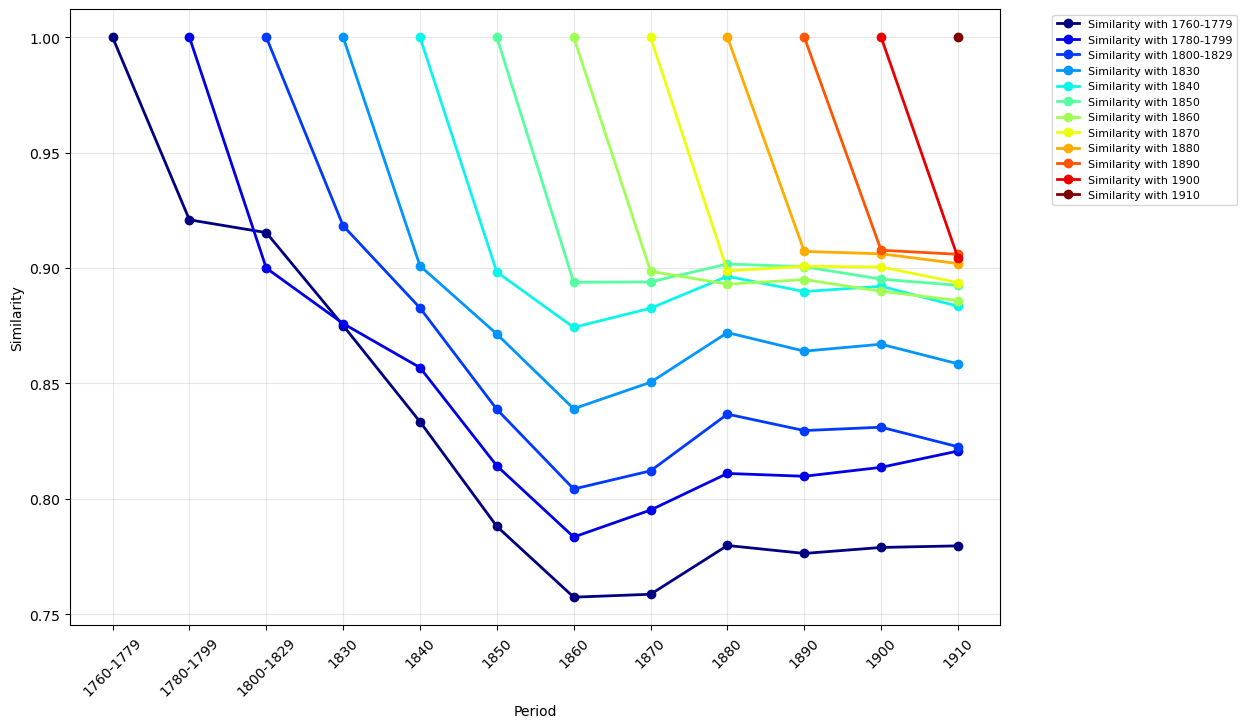

In [88]:
# influence trajectories: similarity decay from each base period
periods_str = [str(p) for p in periods_valid]
plt.figure(figsize=(12, 8))
colors = plt.cm.jet(np.linspace(0, 1, len(periods_valid)))

for i, base_period in enumerate(periods_valid):
    plt.plot(periods_str[i:], downsampled_matrix[i, i:], marker="o", color=colors[i],
             label=f"Similarity with {base_period}", linewidth=2)

plt.xlabel("Period")
plt.ylabel("Similarity")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.savefig("figures/influence_trajectories_downsampled.png", dpi=300, bbox_inches="tight")
plt.show()

#### Revised Fig. 3: single-panel trajectory plot

Each line traces how similar the titles of subsequent decades remain to those of one reference period.
Three early reference periods (1760s, 1800s, 1830s) show the same pattern: decline toward the 1860s, partial recovery in the 1870–80s.

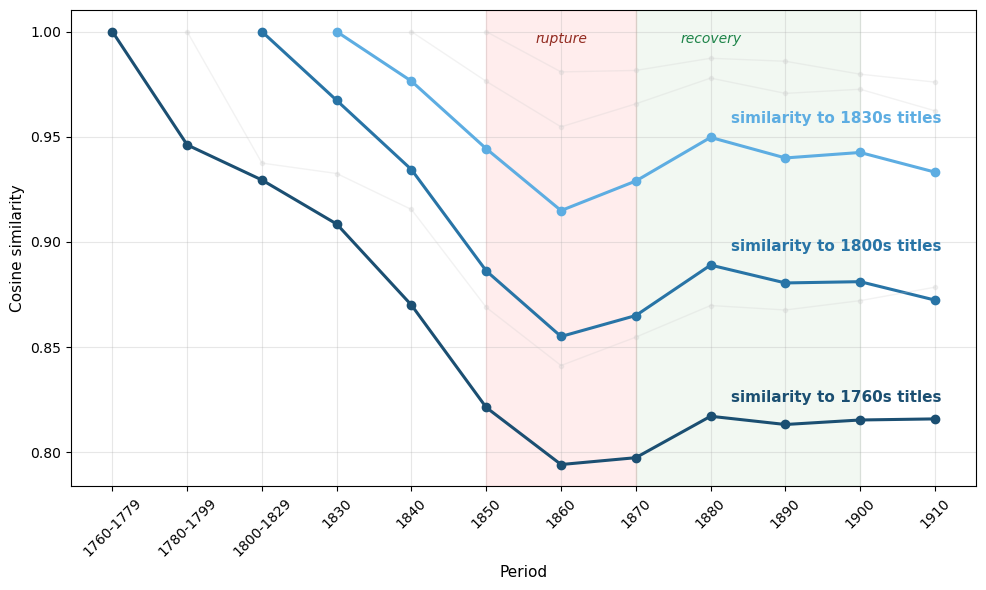

In [89]:
periods_str = [str(p) for p in periods_valid]
period_idx = {str(p): i for i, p in enumerate(periods_valid)}

fig, ax = plt.subplots(figsize=(10, 6))

early = [("similarity to 1760s titles", "1760-1779", "#1b4f72", 8, (15, 8)),
         ("similarity to 1800s titles", "1800-1829", "#2874a6", 6, (15, 8)),
         ("similarity to 1830s titles", "1830", "#5dade2", 5, (15, 8))]

for label, key, color, label_pos, offset in early:
    i = period_idx[key]
    x = periods_str[i:]
    y = full_matrix[i, i:]
    ax.plot(x, y, marker="o", color=color, linewidth=2.2, markersize=6)
    ax.annotate(label, xy=(x[label_pos], y[label_pos]), xytext=offset,
                textcoords="offset points", fontsize=11, color=color,
                fontweight="bold", ha="left", va="bottom")

faded = ["1780-1799", "1840", "1850"]
for key in faded:
    i = period_idx[key]
    x = periods_str[i:]
    y = full_matrix[i, i:]
    ax.plot(x, y, marker="o", color="#cccccc", linewidth=1, markersize=3, alpha=0.25)

ax.axvspan(periods_str.index("1850"), periods_str.index("1870"),
           alpha=0.07, color="red", zorder=0)
ax.text(periods_str.index("1860"), 0.93, "rupture",
        ha="center", fontsize=10, color="#922b21", style="italic",
        transform=ax.get_xaxis_transform())

ax.axvspan(periods_str.index("1870"), periods_str.index("1900"),
           alpha=0.05, color="green", zorder=0)
ax.text(periods_str.index("1880"), 0.93, "recovery",
        ha="center", fontsize=10, color="#1e8449", style="italic",
        transform=ax.get_xaxis_transform())

ax.set_xlabel("Period", fontsize=11)
ax.set_ylabel("Cosine similarity", fontsize=11)
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/fig3_revised.png", dpi=300, bbox_inches="tight")
plt.show()

#### Intra-period diversity

1760-1779: n=12, diversity=0.4193
1780-1799: n=38, diversity=0.4979
1800-1829: n=21, diversity=0.4679
1830: n=161, diversity=0.5059
1840: n=101, diversity=0.5481
1850: n=90, diversity=0.5669
1860: n=114, diversity=0.5775
1870: n=174, diversity=0.5760
1880: n=355, diversity=0.5516
1890: n=444, diversity=0.5493
1900: n=261, diversity=0.5518
1910: n=258, diversity=0.5467


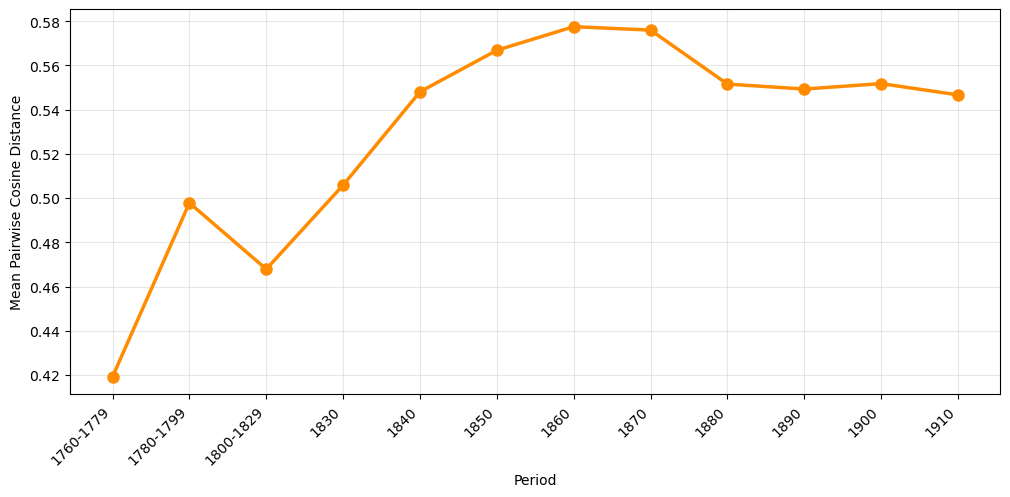

In [90]:
# intra-period diversity: mean pairwise cosine distance
def mean_pairwise_distance(embs, max_pairs=5000):
    n = len(embs)
    if n < 2:
        return np.nan
    pairs_i, pairs_j = np.triu_indices(n, k=1)
    if len(pairs_i) > max_pairs:
        sample = np.random.choice(len(pairs_i), size=max_pairs, replace=False)
        pairs_i, pairs_j = pairs_i[sample], pairs_j[sample]
    return np.mean([cosine(embs[i], embs[j]) for i, j in zip(pairs_i, pairs_j)])

diversity = {}
for p in periods_valid:
    embs = period_embeddings[p]
    diversity[p] = mean_pairwise_distance(embs)
    print(f"{p}: n={len(embs)}, diversity={diversity[p]:.4f}")

plt.figure(figsize=(12, 5))
plt.plot([str(p) for p in periods_valid], [diversity[p] for p in periods_valid],
         marker="o", color="darkorange", linewidth=2.5, markersize=8)
plt.xlabel("Period")
plt.ylabel("Mean Pairwise Cosine Distance")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.savefig("figures/intra_period_diversity.png", dpi=300, bbox_inches="tight")
plt.show()

### Linguistic drift as confound for novelty

Remove punctuation and function words (prepositions, conjunctions, particles), lemmatize content words, re-vectorize with the same SBERT model, compare novelty scores with Spearman correlation.

#### Clean titles

In [91]:
# clean titles: remove function words, lemmatize
morph = pymorphy3.MorphAnalyzer()
FUNC_POS = {"PREP", "CONJ", "PRCL", "INTJ"}

def clean_title(title):
    tokens = re.findall(r"[а-яА-ЯёЁa-zA-Z]+", str(title))
    lemmas = []
    for t in tokens:
        p = morph.parse(t)[0]
        if p.tag.POS not in FUNC_POS:
            lemmas.append(p.normal_form)
    return " ".join(lemmas)

data["title_clean"] = data["title"].apply(clean_title)
data[["title", "title_clean"]].head(20)

,title,title_clean
0,"Награждённая постоянность, или Приключения Лизарка и Сарманды",наградить постоянность приключение лизарка сарманд
1,"Непостоянная фортуна, или Похождения Мирамонда",непостоянный фортуна похождение мирамонд
2,"Приключения Фемистокла и разные политические, гражданские, философические, физические и военные его с сыном своим ра...",приключение фемисточь разный политический гражданский философический физический военный он сын свой разговор постоян...
3,"Пересмешник, или Славенские сказки",пересмешник славенский сказка
4,Письма Эрнеста и Доравры,письмо эрнест доравр
5,"Нума, или процветающий Рим",нум процветать рим
6,"Пригожая повариха, или Похождение развратной женщины",пригожий повариха похождение развратный женщина
7,"Славянские древности, или Приключения славянских князей",славянский древность приключение славянский князь
8,Похождение новомодной красавицы Гуланданы и храброго принца Барама,похождение новомодный красавица гуландать храбрый принц барам
9,"Несчастный Никанор, или Приключение жизни российского дворянина Н********",несчастный никанор приключение жизнь российский дворянин н


#### Re-vectorize cleaned titles with SBERT

In [92]:
# re-vectorize cleaned titles with SBERT
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("ai-forever/sbert_large_nlu_ru")
clean_embeddings = model.encode(data["title_clean"].tolist(), show_progress_bar=True, batch_size=64)
title_to_clean_embedding = dict(zip(data["title"], clean_embeddings))
print(f"encoded {len(title_to_clean_embedding)} cleaned titles")

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

encoded 1973 cleaned titles


#### Compute novelty scores and compare

In [93]:
# compute novelty scores for original and cleaned titles
from tqdm.notebook import tqdm

def compute_novelty(df, emb_dict):
    scores = []
    averaged_embedding = np.zeros(len(next(iter(emb_dict.values()))))
    embedding_count = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc="computing novelty"):
        title = row['title']
        if title not in emb_dict:
            scores.append(np.nan)
            continue
        emb = emb_dict[title]
        if embedding_count > 0:
            scores.append(cosine(emb, averaged_embedding))
        else:
            scores.append(np.nan)
        averaged_embedding = (averaged_embedding * embedding_count + emb) / (embedding_count + 1)
        embedding_count += 1
    return scores

data["novelty_original"] = compute_novelty(data, title_to_embedding)
data["novelty_clean"] = compute_novelty(data, title_to_clean_embedding)

computing novelty:   0%|          | 0/2029 [00:00<?, ?it/s]

computing novelty:   0%|          | 0/2029 [00:00<?, ?it/s]

In [94]:
# spearman correlation: original vs cleaned novelty
valid = data.dropna(subset=["novelty_original", "novelty_clean"])
rho, pval = spearmanr(valid["novelty_original"], valid["novelty_clean"])
print(f"Spearman rho = {rho:.3f}, p = {pval:.2e}, n = {len(valid)}")

Spearman rho = 0.694, p = 3.38e-291, n = 2028


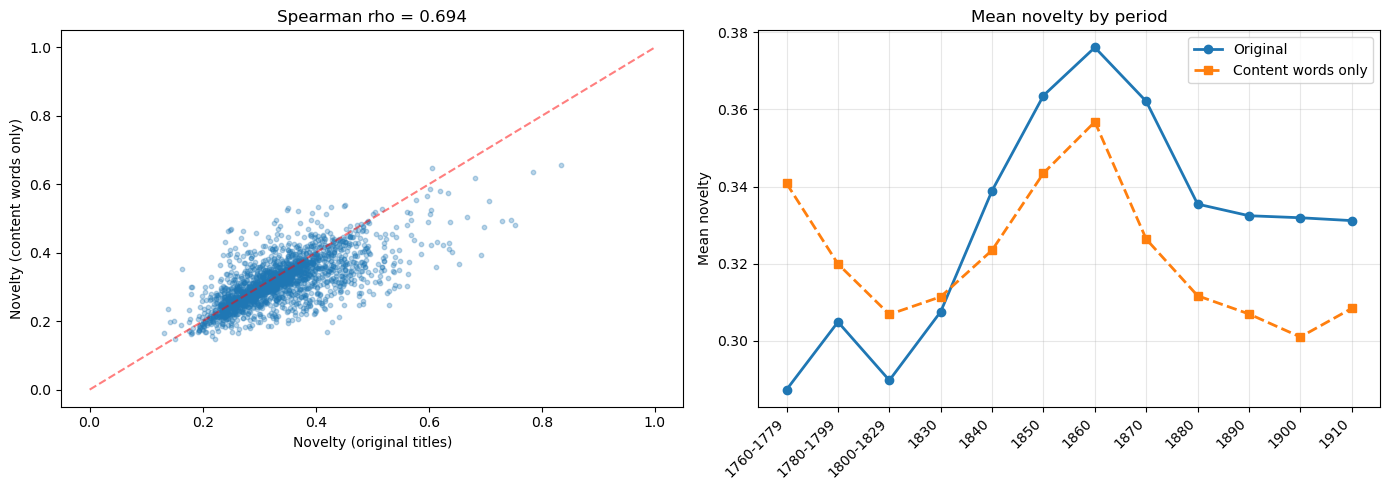

In [95]:
# scatter + line: original vs cleaned novelty comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(valid["novelty_original"], valid["novelty_clean"], alpha=0.3, s=10)
axes[0].plot([0, 1], [0, 1], "r--", alpha=0.5)
axes[0].set_xlabel("Novelty (original titles)")
axes[0].set_ylabel("Novelty (content words only)")
axes[0].set_title(f"Spearman rho = {rho:.3f}")

means_orig = valid.groupby("period")["novelty_original"].mean().reindex(period_order)
means_clean = valid.groupby("period")["novelty_clean"].mean().reindex(period_order)
x = range(len(period_order))
axes[1].plot(x, means_orig, marker="o", label="Original", linewidth=2)
axes[1].plot(x, means_clean, marker="s", linestyle="--", label="Content words only", linewidth=2)
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(p) for p in period_order], rotation=45, ha="right")
axes[1].set_ylabel("Mean novelty")
axes[1].set_title("Mean novelty by period")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/novelty_ablation_linguistic_drift.png", dpi=300, bbox_inches="tight")
plt.show()

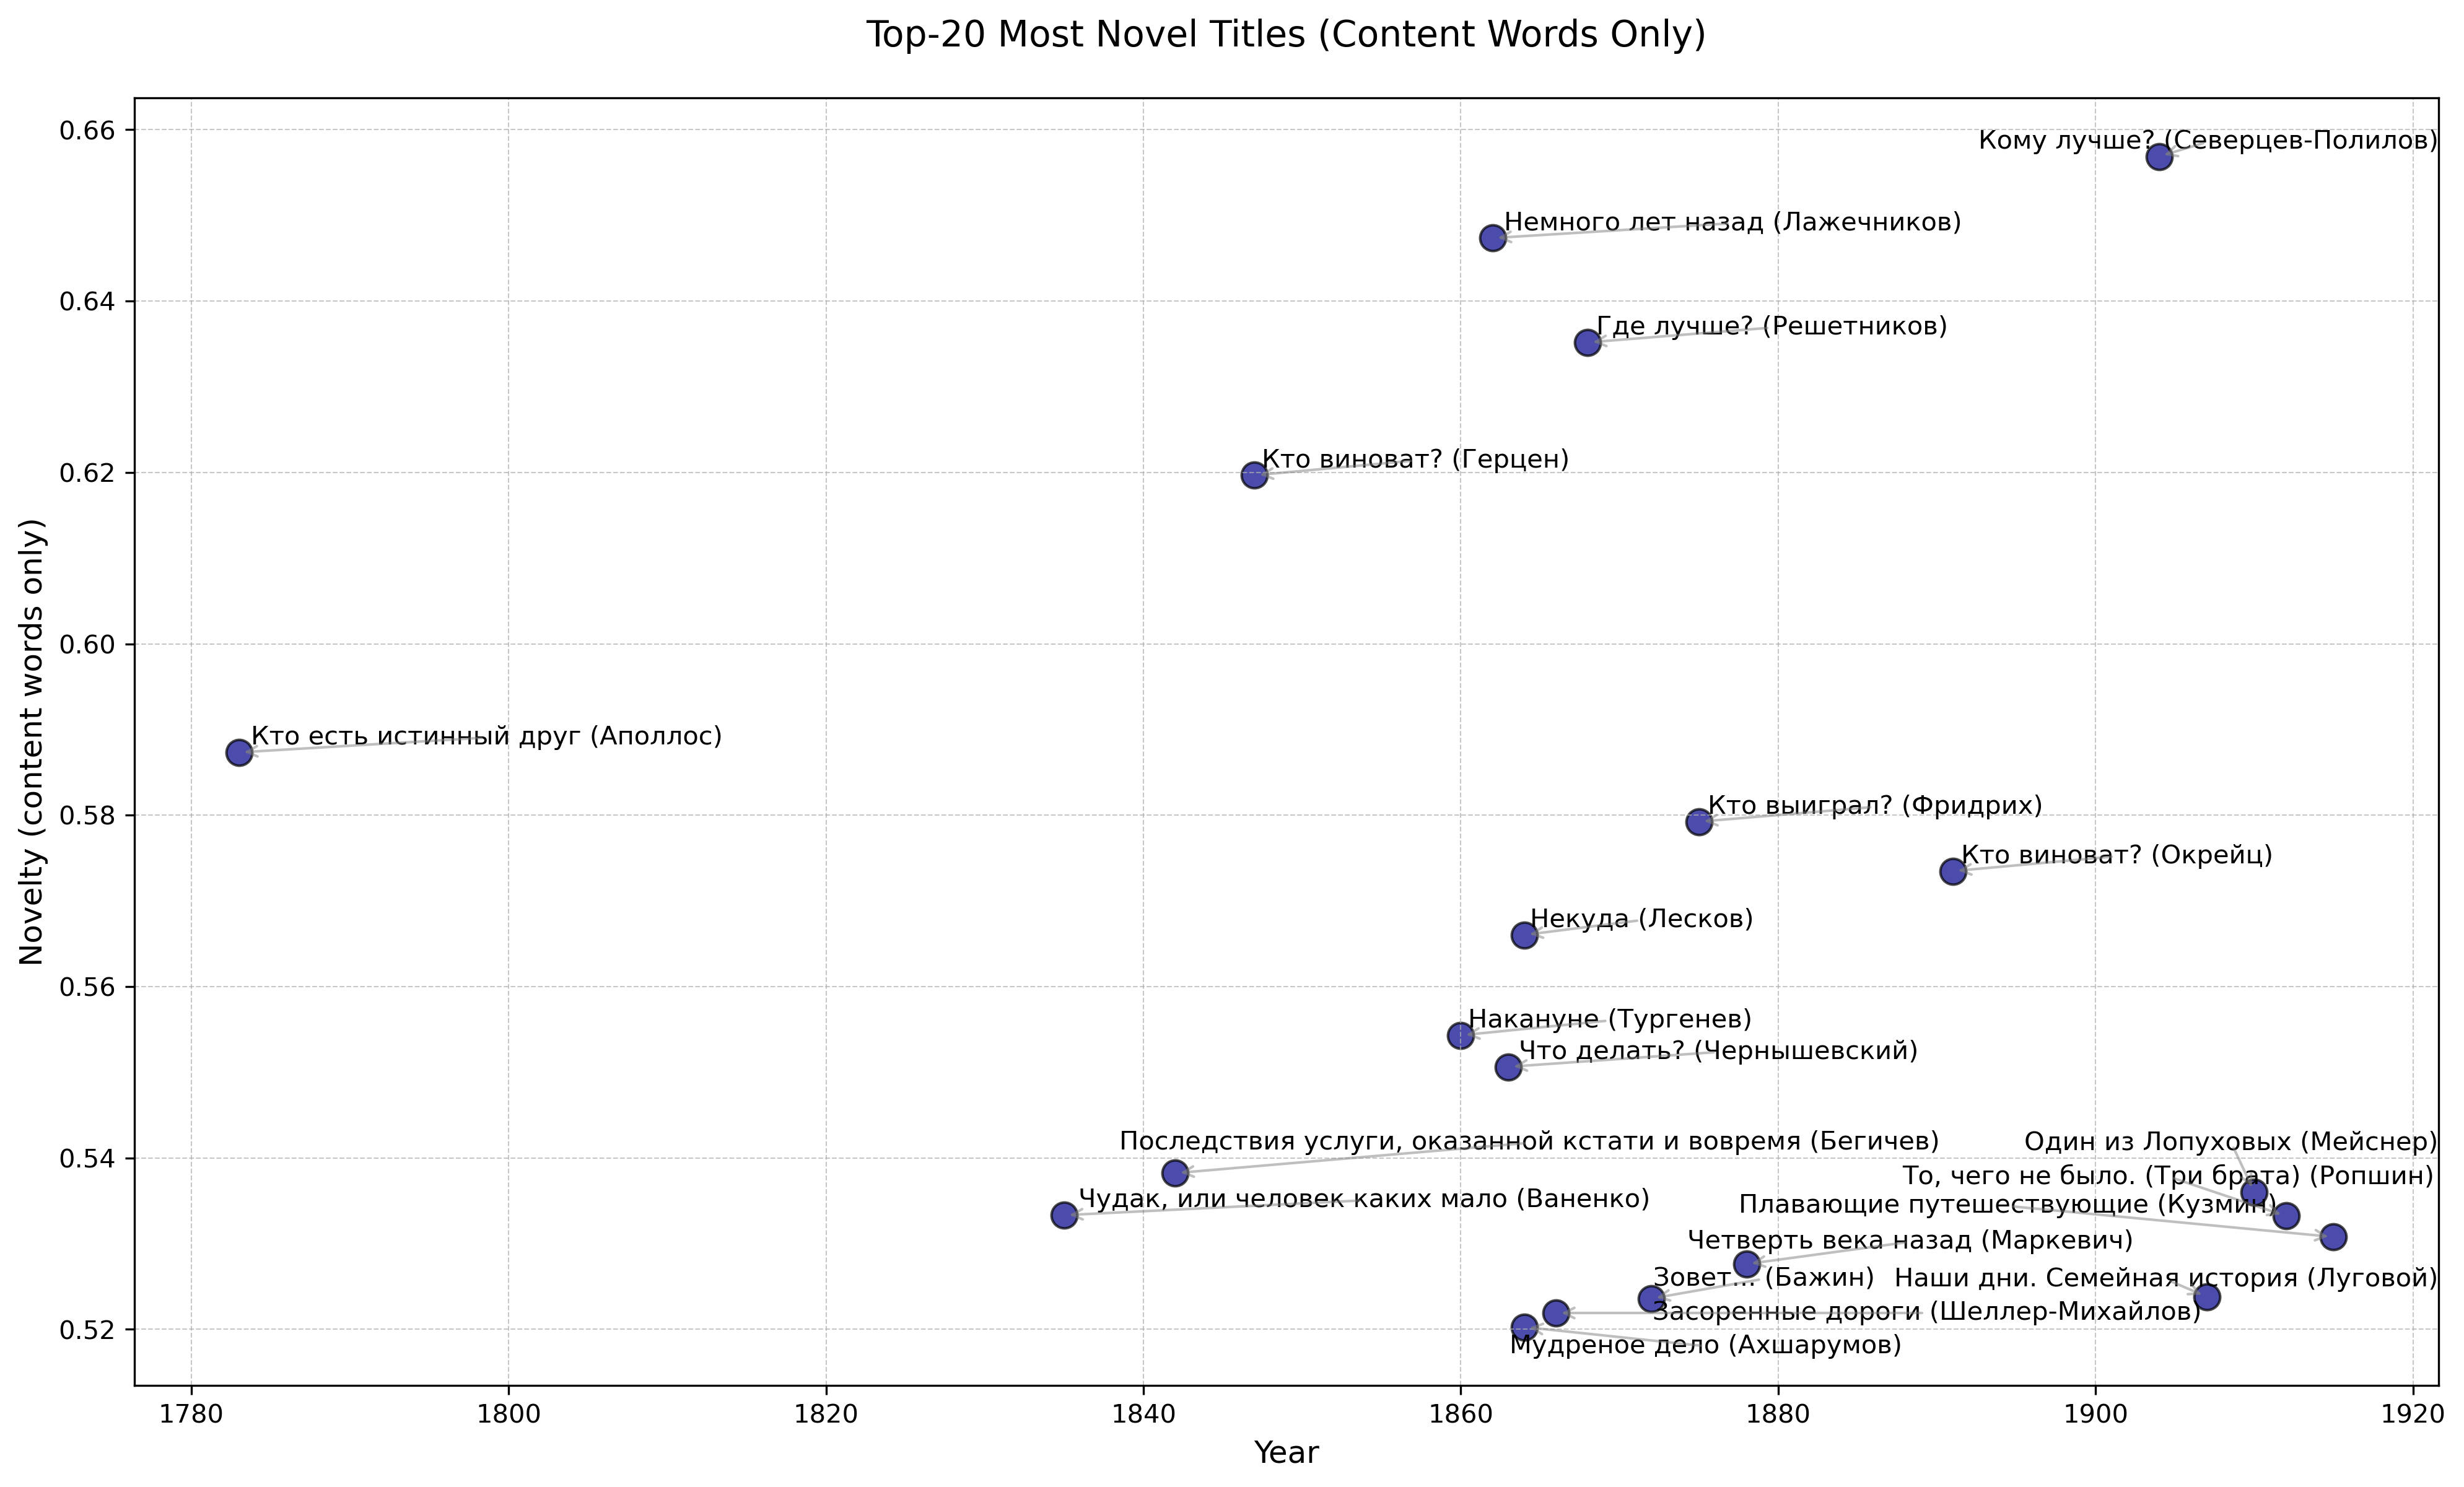

In [96]:
# top-20 most novel titles (cleaned version)
df_top_clean = data.sort_values('novelty_clean', ascending=False).head(20)

plt.figure(figsize=(16, 9), dpi=300)
plt.scatter(df_top_clean['year_begin'], df_top_clean['novelty_clean'],
            color='darkblue', alpha=0.7, s=100, edgecolors='black', linewidth=1)

texts = []
for _, row in df_top_clean.iterrows():
    author_last_name = row['author'].split(',')[0]
    label = f"{row['title']} ({author_last_name})"
    texts.append(plt.text(row['year_begin'], row['novelty_clean'], label))

with contextlib.redirect_stdout(io.StringIO()):
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5),
                expand_points=(1.2, 1.2))

plt.xlabel('Year', fontsize=12)
plt.ylabel('Novelty (content words only)', fontsize=12)
plt.title('Top-20 Most Novel Titles (Content Words Only)', fontsize=14, pad=20)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig('figures/top_novel_titles_clean.png', dpi=300, bbox_inches='tight')
plt.show()

### NOUN NOUN case subtypes

In [97]:
# decompose NOUN NOUN titles by case of the second noun
nn = data[data['POS_title'] == 'NOUN NOUN'].copy()
print(f"NOUN NOUN titles: {len(nn)}")

morph = pymorphy3.MorphAnalyzer()

def get_second_noun_case(title):
    tokens = re.findall(r"[а-яА-ЯёЁ]+", str(title))
    nouns = []
    for t in tokens:
        p = morph.parse(t)[0]
        if p.tag.POS == 'NOUN':
            nouns.append(p)
    if len(nouns) >= 2:
        case = nouns[1].tag.case
        return str(case) if case else 'unknown'
    return 'unknown'

nn['case2'] = nn['title'].apply(get_second_noun_case)

print("\nCase of second noun:")
case_counts = nn['case2'].value_counts()
for case, cnt in case_counts.items():
    print(f"  {case}: {cnt} ({cnt/len(nn)*100:.1f}%)")

print("\nExamples per case:")
for case in case_counts.index[:6]:
    examples = nn[nn['case2'] == case].head(10)
    print(f"\n  {case}:")
    for _, row in examples.iterrows():
        print(f"    {row['title']} ({row['year_begin']})")

NOUN NOUN titles: 273

Case of second noun:
  gent: 151 (55.3%)
  nomn: 93 (34.1%)
  unknown: 22 (8.1%)
  accs: 5 (1.8%)
  loct: 1 (0.4%)
  datv: 1 (0.4%)

Examples per case:

  gent:
    Игра судьбы (1789)
    Часы задумчивости (1799)
    Иона Фаддеевича (1832)
    Иван Мазепа (1832)
    Регенство Бирона (1834)
    Предки Калимероса (1836)
    Елена Волхова (1836)
    Жертва случая (1837)
    Сын актрисы (1838)
    Тайна жизни (1845)

  nomn:
    Письма Скимнина (1813)
    Иван Выжигин (1829)
    Димитрий Самозванец (1830)
    Княжна Меншикова (1833)
    Аскольдова могила (1833)
    Федюша Мотовильский (1833)
    Виктор Полинский (1834)
    Стенька Разин (1837)
    Теодор Станиславский (1838)
    Генерал Каломерос (1840)

  unknown:
    Черный таракан (1843)
    Черный ворон (1853)
    Новые места (1867)
    Горячее время (1871)
    Старые гнезда (1875)
    Молодые побеги (1879)
    Чужие грехи (1880)
    Лесной бродяга (1884)
    Дорогою ценой (1885)
    Черный год (1888)

  accs:
  

In [98]:
# refine NOUN NOUN subtypes using capitalization + case
def nn_subtype(row):
    tokens = str(row['title']).split()
    if len(tokens) < 2:
        return 'other'
    second = tokens[1].strip(',;:.')
    if second and second[0].isupper():
        return 'proper_name'
    if row['case2'] == 'gent':
        return 'genitive'
    return 'other'

nn['subtype'] = nn.apply(nn_subtype, axis=1)

print("NOUN NOUN subtypes:")
for st, cnt in nn['subtype'].value_counts().items():
    print(f"  {st}: {cnt} ({cnt/len(nn)*100:.1f}%)")

print("\nExamples:")
for st in ['proper_name', 'genitive', 'other']:
    sub = nn[nn['subtype'] == st]
    if len(sub) == 0:
        continue
    print(f"\n  {st} (n={len(sub)}):")
    for _, row in sub.head(20).iterrows():
        print(f"    {row['title']} ({row['year_begin']})")

NOUN NOUN subtypes:
  genitive: 111 (40.7%)
  proper_name: 111 (40.7%)
  other: 51 (18.7%)

Examples:

  proper_name (n=111):
    Письма Скимнина (1813)
    Иван Выжигин (1829)
    Димитрий Самозванец (1830)
    Иона Фаддеевича (1832)
    Иван Мазепа (1832)
    Княжна Меншикова (1833)
    Федюша Мотовильский (1833)
    Регенство Бирона (1834)
    Виктор Полинский (1834)
    Предки Калимероса (1836)
    Елена Волхова (1836)
    Стенька Разин (1837)
    Теодор Станиславский (1838)
    Генерал Каломерос (1840)
    Дурочка Луиза (1842)
    Князь Курбский (1843)
    Баронесса Флагсберг (1848)
    Жак Бичовкин (1849)
    Алексей Однорог (1852)
    Марья Ивановна (1853)

  genitive (n=111):
    Игра судьбы (1789)
    Часы задумчивости (1799)
    Жертва случая (1837)
    Сын актрисы (1838)
    Тайна жизни (1845)
    Дочь шута (1848)
    Семья ассессорши (1848)
    Мелочи жизни (1854)
    Тысяча душ (1858)
    Болезни воли (1859)
    Банк тщеславия (1861)
    Записки холостяка (1861)
    Типы п

In [99]:
# semantic classification of nouns via RuWordNet hypernyms
from ruwordnet import RuWordNet
wn = RuWordNet()

def get_top_hypernym(word, depth=4):
    """walk up the hypernym tree, return the highest-level synset title"""
    synsets = wn.get_synsets(word)
    if not synsets:
        return None
    current = synsets[0]
    chain = [current.title]
    for _ in range(depth):
        hypers = current.hypernyms
        if not hypers:
            break
        current = hypers[0]
        chain.append(current.title)
    return chain[-1]

def get_mid_hypernym(word, depth=2):
    """walk up 2 levels -- more informative than root"""
    synsets = wn.get_synsets(word)
    if not synsets:
        return None
    current = synsets[0]
    for _ in range(depth):
        hypers = current.hypernyms
        if not hypers:
            break
        current = hypers[0]
    return current.title

# extract both nouns from NOUN NOUN titles
def extract_nouns(title):
    tokens = re.findall(r"[а-яА-ЯёЁ]+", str(title))
    nouns = []
    for t in tokens:
        p = morph.parse(t)[0]
        if p.tag.POS == 'NOUN':
            nouns.append(p.normal_form)
    return nouns

nn['nouns'] = nn['title'].apply(extract_nouns)
nn['noun1'] = nn['nouns'].apply(lambda x: x[0] if len(x) >= 1 else None)
nn['noun2'] = nn['nouns'].apply(lambda x: x[1] if len(x) >= 2 else None)

# classify genitive subtitles only (proper names are already classified)
gen = nn[nn['subtype'] == 'genitive'].copy()
gen['n1_mid'] = gen['noun1'].apply(lambda w: get_mid_hypernym(w) if w else None)
gen['n2_mid'] = gen['noun2'].apply(lambda w: get_mid_hypernym(w) if w else None)
gen['n1_top'] = gen['noun1'].apply(lambda w: get_top_hypernym(w) if w else None)
gen['n2_top'] = gen['noun2'].apply(lambda w: get_top_hypernym(w) if w else None)

print(f"Genitive NOUN NOUN titles: {len(gen)}")
print(f"\nNoun 1 (head) -- mid-level hypernyms:")
print(gen['n1_mid'].value_counts().head(15))
print(f"\nNoun 2 (dependent) -- mid-level hypernyms:")
print(gen['n2_mid'].value_counts().head(15))

print("\n\nSample titles with classification:")
for _, row in gen.head(20).iterrows():
    print(f"  {row['title']:40s}  N1={str(row['noun1']):15s} -> {str(row['n1_mid']):30s}  N2={str(row['noun2']):15s} -> {str(row['n2_mid'])}")

Genitive NOUN NOUN titles: 111

Noun 1 (head) -- mid-level hypernyms:
n1_mid
БИОЛОГИЧЕСКАЯ СУЩНОСТЬ           8
СУБЪЕКТ ДЕЯТЕЛЬНОСТИ             7
ЛИСТ (ПЛАСТ)                     6
ЧЕЛОВЕК                          6
СОБЫТИЕ, ФАКТ                    6
РОДСТВЕННИК                      6
СВОЙСТВО, ХАРАКТЕРИСТИКА         5
МЕСТО В ПРОСТРАНСТВЕ             2
САМОЧУВСТВИЕ                     2
ОТВЕТИТЬ, ПОСТУПИТЬ В ОТВЕТ      2
ГЛАВА ГОСУДАРСТВА                2
РОЛЬ, ПОЛОЖЕНИЕ, МЕСТО           2
ОБЪЯВИТЬ, ОГЛАСИТЬ               2
ВОЗМОЖНОСТЬ ДЛЯ ОСУЩЕСТВЛЕНИЯ    2
СОСТАВНАЯ ЧАСТЬ                  2
Name: count, dtype: int64

Noun 2 (dependent) -- mid-level hypernyms:
n2_mid
СОСТОЯНИЕ, ВНУТРЕННИЕ ОБСТОЯТЕЛЬСТВА    14
МЕНТАЛЬНЫЙ ОБЪЕКТ                        8
ФИЗИЧЕСКАЯ СУЩНОСТЬ                      5
МЕСТО В ПРОСТРАНСТВЕ                     5
ЧЕЛОВЕК                                  4
ОПИСАНИЕ (ТЕКСТ)                         3
ВРЕМЯ, ПРОДОЛЖИТЕЛЬНОСТЬ                 3
ЭТНИЧЕСКАЯ ОБЩНОСТЬ 

### Genre analysis

general_genre: 1657 / 2029 (81.7%), 21 categories


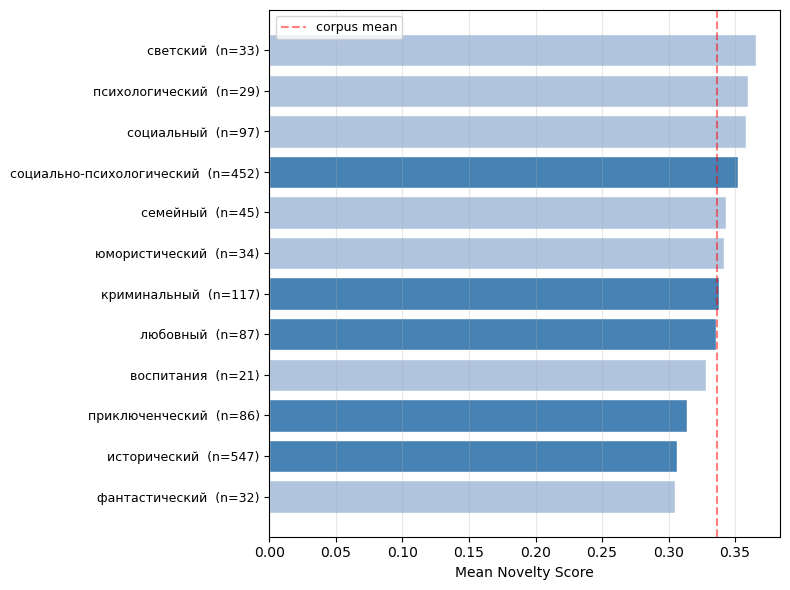

                             n  mean_novelty
general_genre                               
фантастический              32         0.305
исторический               547         0.307
приключенческий             86         0.314
воспитания                  21         0.328
любовный                    87         0.335
криминальный               117         0.338
юмористический              34         0.342
семейный                    45         0.343
социально-психологический  452         0.352
социальный                  97         0.358
психологический             29         0.360
светский                    33         0.366


In [100]:
# genre coverage + horizontal bar: mean novelty by genre (n>=20)
gg = data['general_genre'].dropna()
print(f"general_genre: {len(gg)} / {len(data)} ({len(gg)/len(data)*100:.1f}%), {gg.nunique()} categories")

genre_stats = (
    data[data['general_genre'].notna()]
    .groupby('general_genre')
    .agg(n=('title', 'count'), mean_novelty=('novelty_original', 'mean'))
    .sort_values('mean_novelty', ascending=True)
)

min_n = 20
gs = genre_stats[genre_stats['n'] >= min_n]

fig, ax = plt.subplots(figsize=(8, 6))
top5_set = {'социально-психологический', 'исторический', 'криминальный', 'любовный', 'приключенческий'}
colors = ['steelblue' if g in top5_set else 'lightsteelblue' for g in gs.index]
ax.barh(range(len(gs)), gs['mean_novelty'], color=colors, edgecolor='white')
ax.set_yticks(range(len(gs)))
ax.set_yticklabels([f"{g}  (n={n})" for g, n in zip(gs.index, gs['n'])], fontsize=9)
ax.set_xlabel('Mean Novelty Score')
ax.axvline(data['novelty_original'].dropna().mean(), color='red', linestyle='--', alpha=0.5, label='corpus mean')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('figures/novelty_by_genre_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print(gs[['n', 'mean_novelty']].round(3))

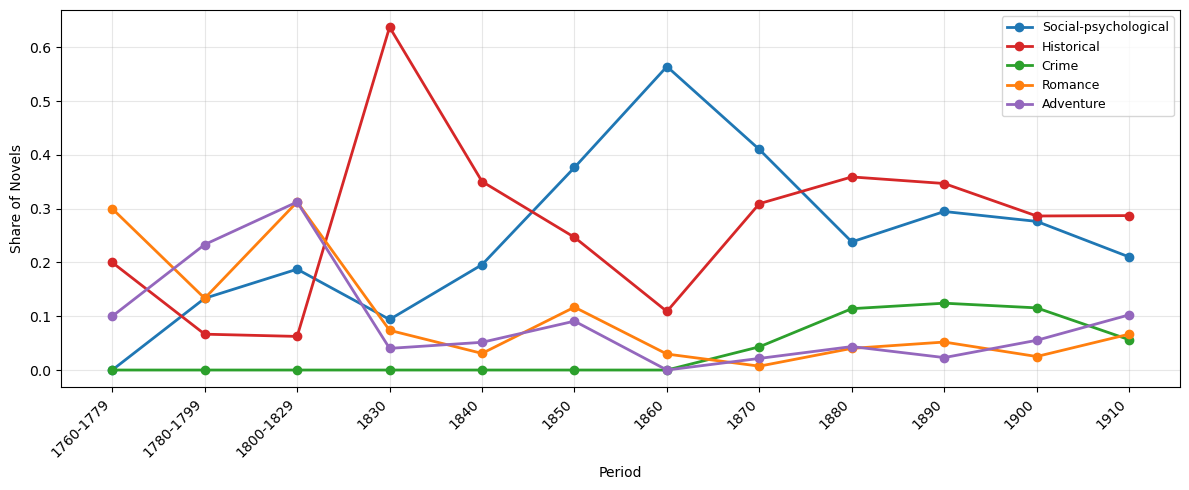

general_genre  социально-психологический  исторический  криминальный  \
period                                                                 
1760-1779                          0.000         0.200         0.000   
1780-1799                          0.133         0.067         0.000   
1800-1829                          0.188         0.062         0.000   
1830                               0.094         0.638         0.000   
1840                               0.196         0.351         0.000   
1850                               0.377         0.247         0.000   
1860                               0.564         0.109         0.000   
1870                               0.410         0.309         0.043   
1880                               0.238         0.359         0.114   
1890                               0.295         0.347         0.124   
1900                               0.276         0.286         0.116   
1910                               0.210         0.287         0

In [101]:
# define top5 genres, labels, palette; line chart of genre shares
top5 = ['социально-психологический', 'исторический', 'криминальный',
        'любовный', 'приключенческий']
genre_labels = {
    'социально-психологический': 'Social-psychological',
    'исторический': 'Historical',
    'криминальный': 'Crime',
    'любовный': 'Romance',
    'приключенческий': 'Adventure'
}
palette = {
    'социально-психологический': '#1f77b4',
    'исторический': '#d62728',
    'криминальный': '#2ca02c',
    'любовный': '#ff7f0e',
    'приключенческий': '#9467bd'
}

comp = (
    data[data['general_genre'].isin(top5)]
    .groupby(['period', 'general_genre']).size()
    .reset_index(name='count')
)
total = data[data['general_genre'].notna()].groupby('period').size()
comp['share'] = comp.apply(lambda r: r['count'] / total[r['period']], axis=1)
pivot_comp = comp.pivot(index='period', columns='general_genre', values='share').reindex(period_order).fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
for g in top5:
    if g in pivot_comp.columns:
        ax.plot(range(len(period_order)), pivot_comp[g].values,
                marker='o', linewidth=2, markersize=6,
                label=genre_labels[g], color=palette[g])

ax.set_xticks(range(len(period_order)))
ax.set_xticklabels([str(p) for p in period_order], rotation=45, ha='right')
ax.set_xlabel('Period')
ax.set_ylabel('Share of Novels')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/genre_composition_period.png', dpi=300, bbox_inches='tight')
plt.show()

print(pivot_comp[top5].round(3))

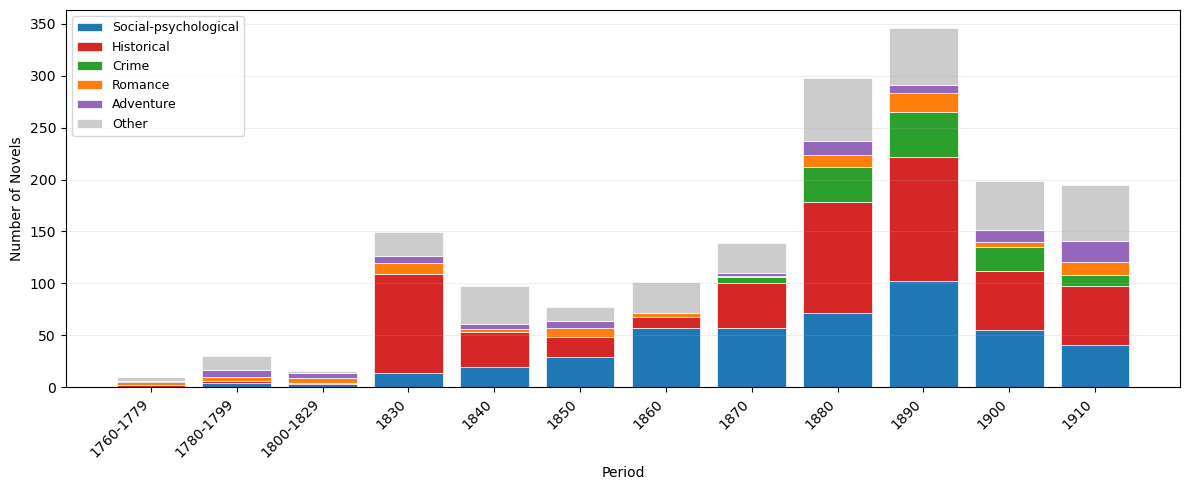

In [102]:
# stacked bar: genre composition by period (absolute counts)
total_by_period = data[data['general_genre'].notna()].groupby('period').size()
top5_by_period = (
    data[data['general_genre'].isin(top5)]
    .groupby(['period', 'general_genre']).size()
    .reset_index(name='count')
    .pivot(index='period', columns='general_genre', values='count')
    .reindex(period_order).fillna(0)
)
other_counts = total_by_period - top5_by_period[top5].sum(axis=1)
top5_by_period['Other'] = other_counts.reindex(period_order).fillna(0)

plot_order = top5 + ['Other']
plot_labels = {**genre_labels, 'Other': 'Other'}
plot_palette = {**palette, 'Other': '#cccccc'}

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(period_order))
for g in plot_order:
    vals = top5_by_period[g].values
    ax.bar(range(len(period_order)), vals, bottom=bottom,
           label=plot_labels[g], color=plot_palette[g], edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_xticks(range(len(period_order)))
ax.set_xticklabels([str(p) for p in period_order], rotation=45, ha='right')
ax.set_xlabel('Period')
ax.set_ylabel('Number of Novels')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('figures/genre_composition_stacked_bar.png', dpi=300, bbox_inches='tight')
plt.show()

In [103]:
# raw counts table
top5_by_period

general_genre,исторический,криминальный,любовный,приключенческий,социально-психологический,Other
period,,,,,,
1760-1779,2.0,0.0,3.0,1.0,0.0,4.0
1780-1799,2.0,0.0,4.0,7.0,4.0,13.0
1800-1829,1.0,0.0,5.0,5.0,3.0,2.0
1830,95.0,0.0,11.0,6.0,14.0,23.0
1840,34.0,0.0,3.0,5.0,19.0,36.0
1850,19.0,0.0,9.0,7.0,29.0,13.0
1860,11.0,0.0,3.0,0.0,57.0,30.0
1870,43.0,6.0,1.0,3.0,57.0,29.0
1880,107.0,34.0,12.0,13.0,71.0,61.0


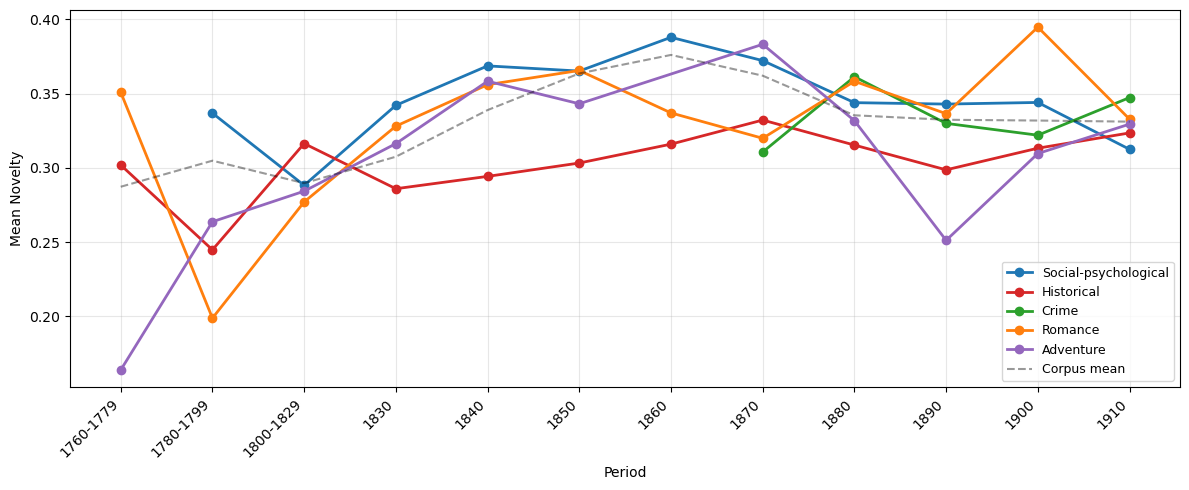

In [104]:
# line chart: novelty by genre x period
gp = (
    data[data['general_genre'].isin(top5)]
    .groupby(['period', 'general_genre'])
    .agg(mean_novelty=('novelty_original', 'mean'), n=('title', 'count'))
    .reset_index()
)

corpus_mean = data.groupby('period')['novelty_original'].mean().reindex(period_order)

fig, ax = plt.subplots(figsize=(12, 5))
for g in top5:
    sub = gp[gp['general_genre'] == g].set_index('period').reindex(period_order)
    vals = sub['mean_novelty']
    x = [i for i, v in enumerate(vals) if pd.notna(v)]
    y = [v for v in vals if pd.notna(v)]
    ax.plot(x, y, marker='o', linewidth=2, markersize=6,
            label=genre_labels[g], color=palette[g])

ax.plot(range(len(period_order)), corpus_mean.values,
        'k--', alpha=0.4, linewidth=1.5, label='Corpus mean')

ax.set_xticks(range(len(period_order)))
ax.set_xticklabels([str(p) for p in period_order], rotation=45, ha='right')
ax.set_xlabel('Period')
ax.set_ylabel('Mean Novelty')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/novelty_by_genre_period.png', dpi=300, bbox_inches='tight')
plt.show()

In [105]:
# data tables: mean novelty and N by genre x period
pivot_nov = gp.pivot(index='period', columns='general_genre', values='mean_novelty').reindex(period_order)
pivot_n = gp.pivot(index='period', columns='general_genre', values='n').reindex(period_order).fillna(0).astype(int)

print("Mean novelty by genre x period:")
print(pivot_nov[top5].round(3))
print("\nN titles per cell:")
print(pivot_n[top5])
print(f"\nCorpus mean by period:")
print(corpus_mean.round(3))

Mean novelty by genre x period:
general_genre  социально-психологический  исторический  криминальный  \
period                                                                 
1760-1779                            NaN         0.302           NaN   
1780-1799                          0.337         0.245           NaN   
1800-1829                          0.288         0.316           NaN   
1830                               0.342         0.286           NaN   
1840                               0.369         0.294           NaN   
1850                               0.365         0.303           NaN   
1860                               0.388         0.316           NaN   
1870                               0.372         0.332         0.311   
1880                               0.344         0.315         0.361   
1890                               0.343         0.299         0.330   
1900                               0.344         0.313         0.322   
1910                            

In [106]:
# top-5 POS patterns per genre
for genre in top5:
    subset = data[data['general_genre'] == genre]
    top_pos = subset['POS_title'].value_counts().head(5)
    total = len(subset)
    print(f"\n{genre_labels[genre]} ({genre}, n={total}):")
    for pos, cnt in top_pos.items():
        print(f"  {pos}: {cnt} ({cnt/total*100:.1f}%)")


Social-psychological (социально-психологический, n=452):
  NOUN: 117 (25.9%)
  ADJF NOUN: 84 (18.6%)
  NOUN NOUN: 58 (12.8%)
  PREP NOUN: 25 (5.5%)
  NOUN CONJ NOUN: 12 (2.7%)

Historical (исторический, n=547):
  NOUN: 86 (15.7%)
  ADJF NOUN: 76 (13.9%)
  NOUN NOUN: 71 (13.0%)
  NOUN CONJ NOUN: 18 (3.3%)
  NOUN NOUN NOUN: 17 (3.1%)

Crime (криминальный, n=117):
  ADJF NOUN: 25 (21.4%)
  NOUN: 17 (14.5%)
  NOUN NOUN: 16 (13.7%)
  PREP NOUN NOUN: 11 (9.4%)
  PREP NOUN: 9 (7.7%)

Romance (любовный, n=87):
  NOUN NOUN: 14 (16.1%)
  NOUN: 13 (14.9%)
  ADJF NOUN: 6 (6.9%)
  PREP NOUN NOUN: 6 (6.9%)
  PREP NOUN: 4 (4.6%)

Adventure (приключенческий, n=86):
  ADJF NOUN: 13 (15.1%)
  NOUN NOUN: 13 (15.1%)
  NOUN: 12 (14.0%)
  NOUN NOUN NOUN: 5 (5.8%)
  NOUN ADJF NOUN: 4 (4.7%)


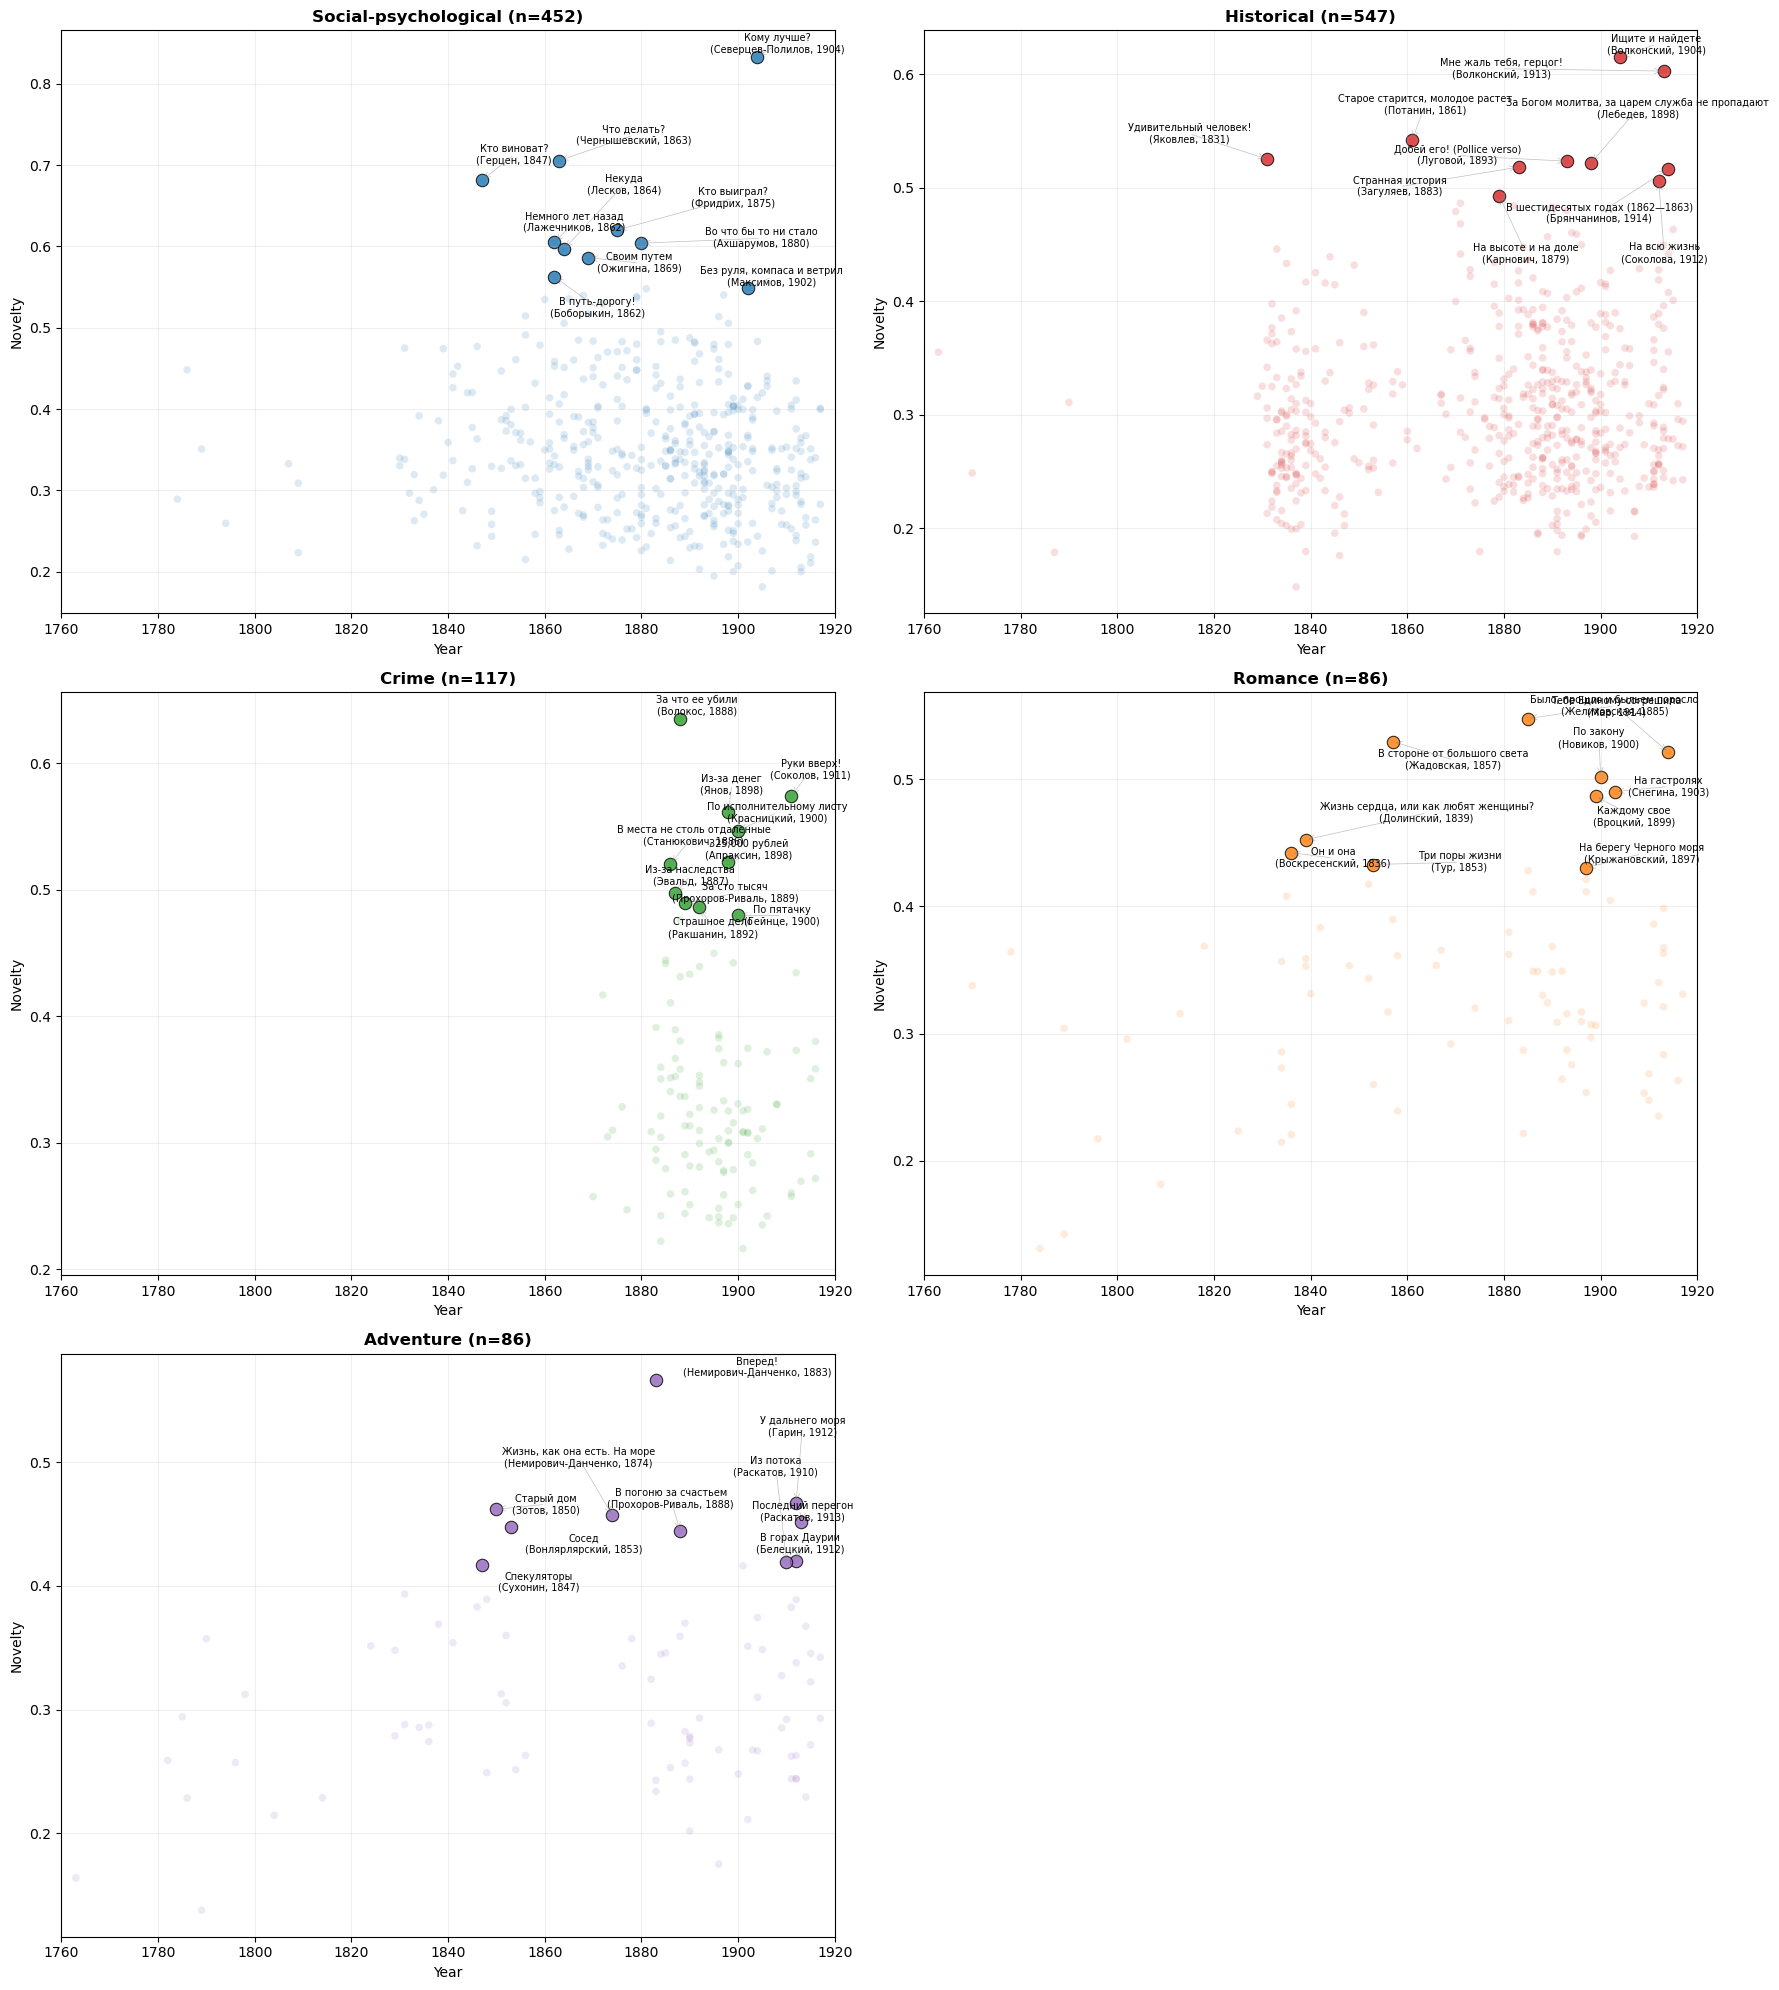


Social-psychological -- top 10 most innovative (mean=0.352, n=452)
   1. [0.833] Кому лучше? -- Северцев-Полилов, 1904
   2. [0.706] Что делать? -- Чернышевский, 1863
   3. [0.681] Кто виноват? -- Герцен, 1847
   4. [0.620] Кто выиграл? -- Фридрих, 1875
   5. [0.605] Немного лет назад -- Лажечников, 1862
   6. [0.604] Во что бы то ни стало -- Ахшарумов, 1880
   7. [0.597] Некуда -- Лесков, 1864
   8. [0.586] Своим путем -- Ожигина, 1869
   9. [0.563] В путь-дорогу! -- Боборыкин, 1862
  10. [0.549] Без руля, компаса и ветрил -- Максимов, 1902

Historical -- top 10 most innovative (mean=0.307, n=547)
   1. [0.615] Ищите и найдете -- Волконский, 1904
   2. [0.603] Мне жаль тебя, герцог! -- Волконский, 1913
   3. [0.542] Старое старится, молодое растет -- Потанин, 1861
   4. [0.525] Удивительный человек! -- Яковлев, 1831
   5. [0.523] Добей его! (Pollice verso) -- Луговой, 1893
   6. [0.522] За Богом молитва, за царем служба не пропадают -- Лебедев, 1898
   7. [0.518] Странная история -- 

In [107]:
# top-10 most innovative titles per genre: scatter + text
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
axes = axes.flatten()

for idx, genre in enumerate(top5):
    ax = axes[idx]
    subset = data[(data['general_genre'] == genre) & data['novelty_original'].notna()]
    top_n = subset.sort_values('novelty_original', ascending=False).head(10)

    ax.scatter(subset['year_begin'], subset['novelty_original'],
               color=palette[genre], alpha=0.15, s=30, edgecolors='none')
    ax.scatter(top_n['year_begin'], top_n['novelty_original'],
               color=palette[genre], alpha=0.8, s=80, edgecolors='black', linewidth=0.8)

    texts = []
    for _, row in top_n.iterrows():
        author_last = row['author'].split(',')[0]
        label = f"{row['title']}\n({author_last}, {row['year_begin']})"
        texts.append(ax.text(row['year_begin'], row['novelty_original'], label, fontsize=7))

    with contextlib.redirect_stdout(io.StringIO()):
        adjust_text(texts, ax=ax,
                    arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=0.5),
                    expand_points=(1.5, 1.5))

    ax.set_title(f"{genre_labels[genre]} (n={len(subset)})", fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Novelty')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(1760, 1920)

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('figures/top_novel_titles_by_genre.png', dpi=300, bbox_inches='tight')
plt.show()

for genre in top5:
    subset = data[(data['general_genre'] == genre) & data['novelty_original'].notna()]
    top_n = subset.sort_values('novelty_original', ascending=False).head(10)
    print(f"\n{genre_labels[genre]} -- top 10 most innovative (mean={subset['novelty_original'].mean():.3f}, n={len(subset)})")
    for i, (_, row) in enumerate(top_n.iterrows(), 1):
        author_last = row['author'].split(',')[0]
        print(f"  {i:2d}. [{row['novelty_original']:.3f}] {row['title']} -- {author_last}, {row['year_begin']}")

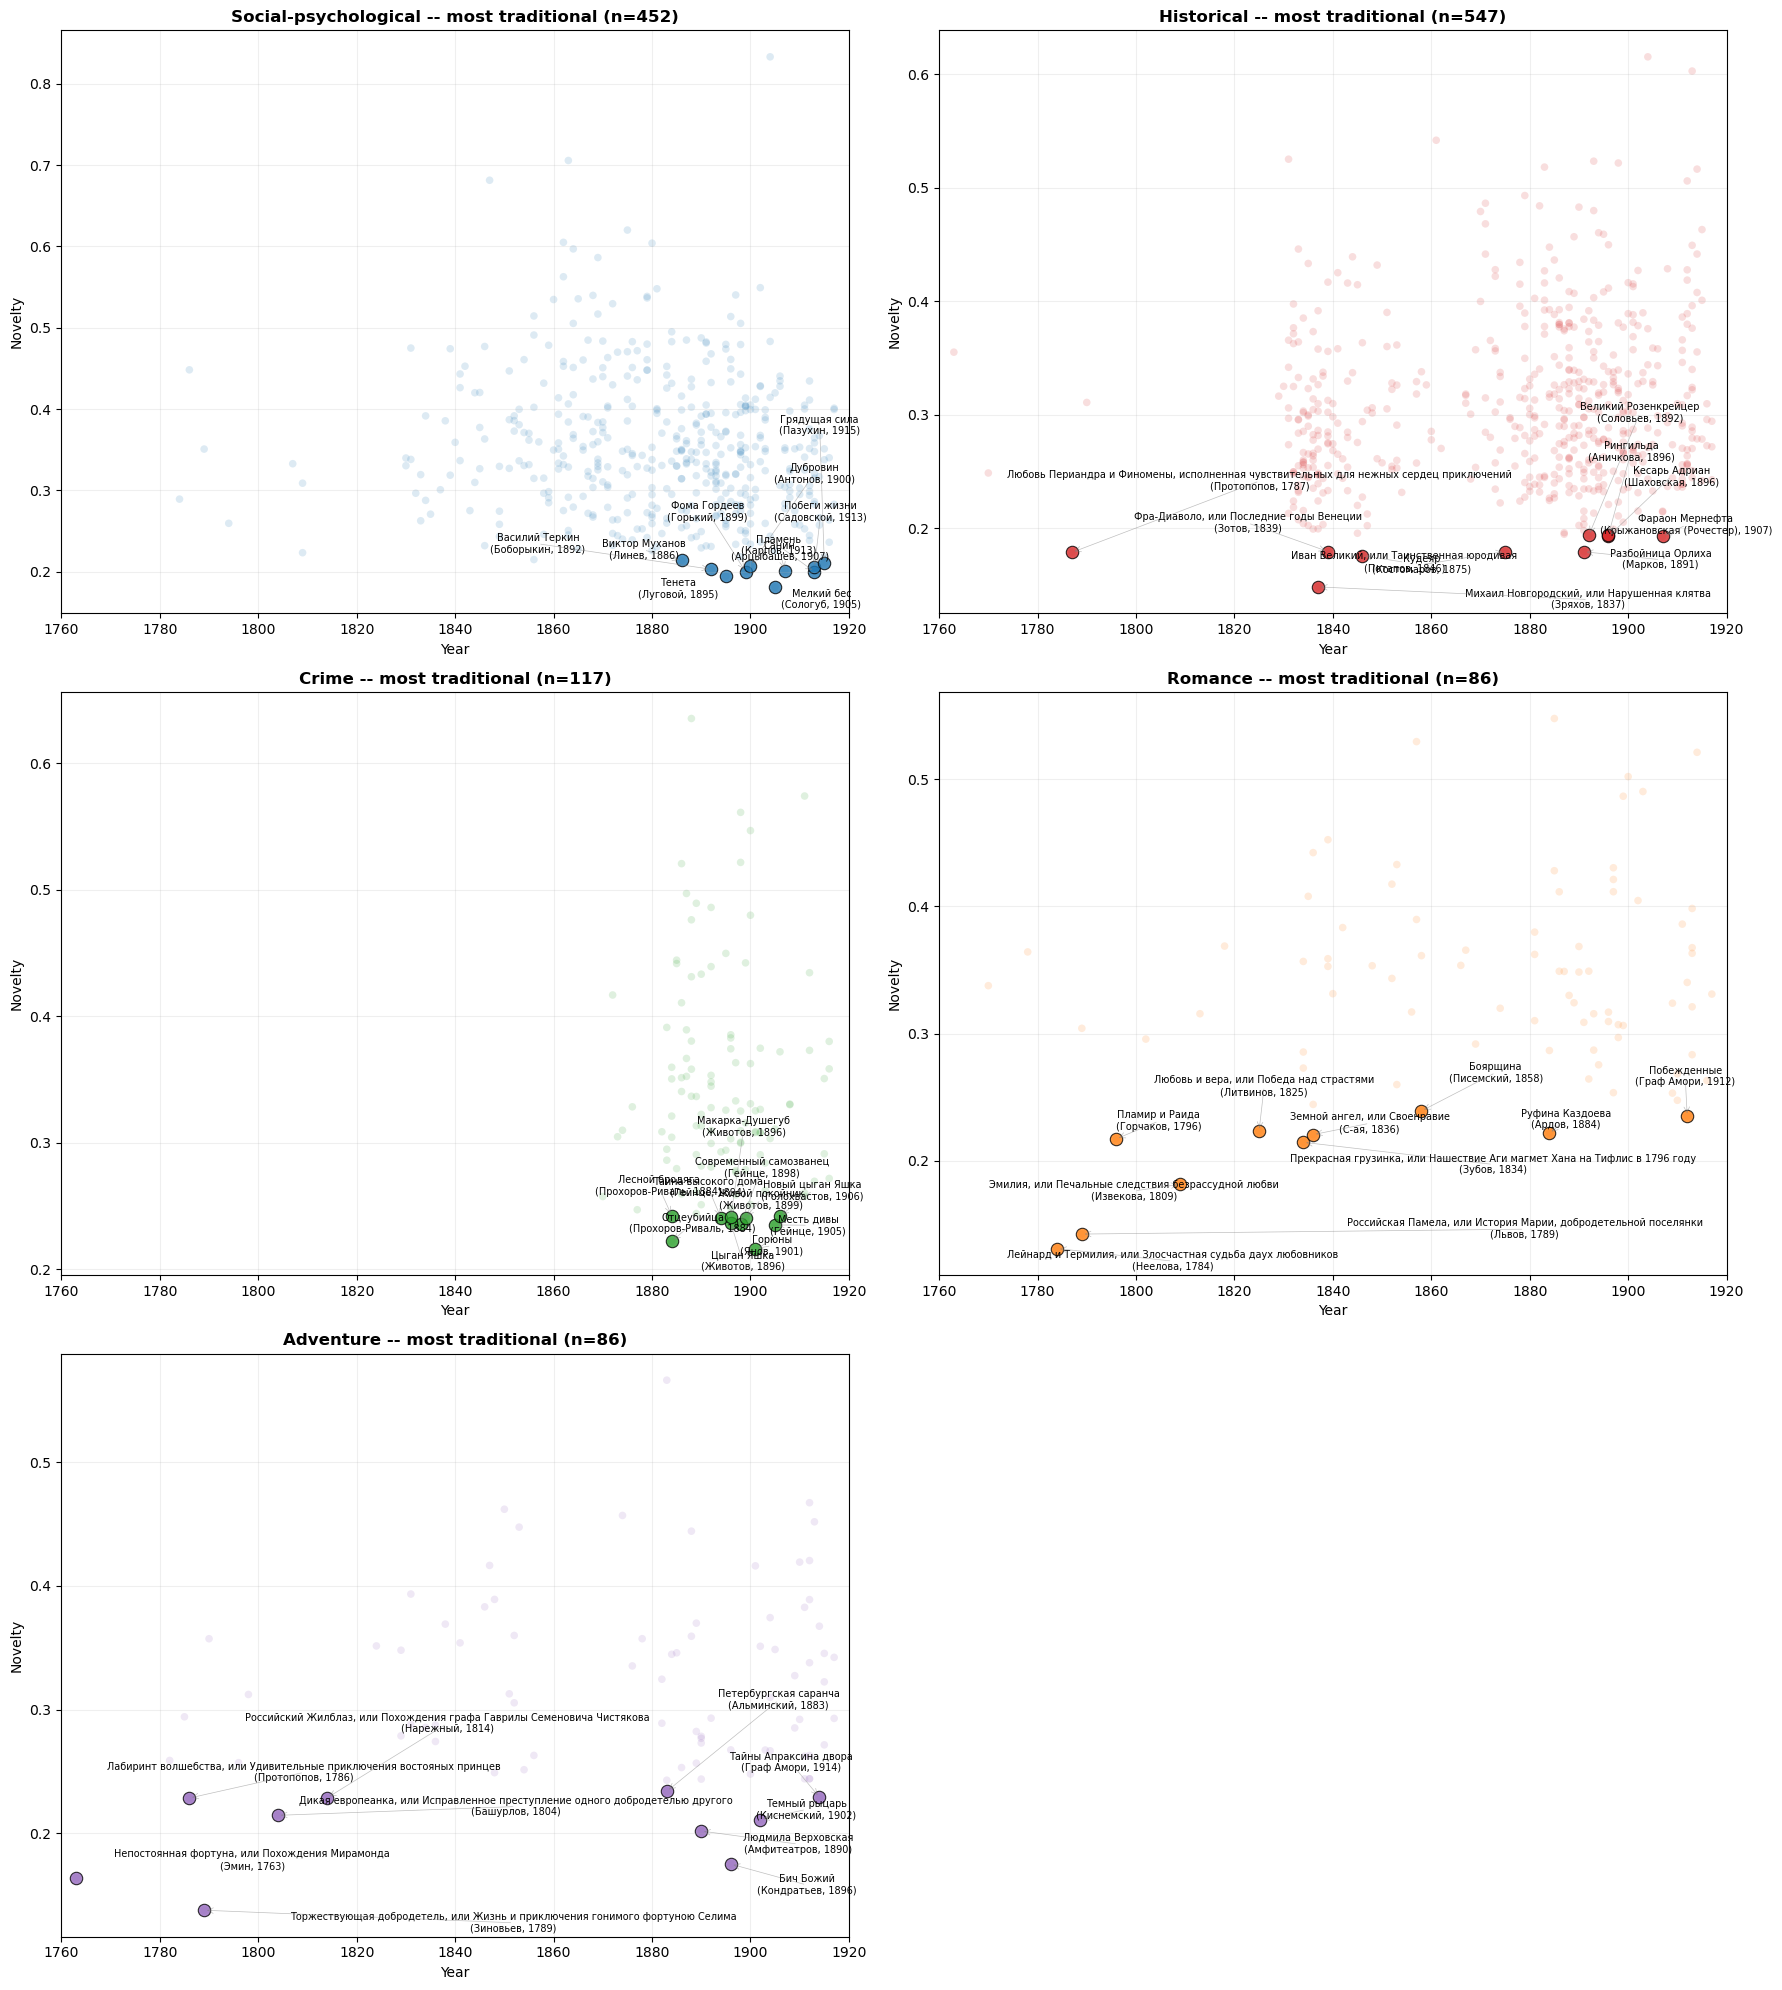


Social-psychological -- top 10 most traditional (mean=0.352, n=452)
   1. [0.181] Мелкий бес -- Сологуб, 1905
   2. [0.195] Тенета -- Луговой, 1895
   3. [0.200] Пламень -- Карпов, 1913
   4. [0.200] Фома Гордеев -- Горький, 1899
   5. [0.201] Санин -- Арцыбашев, 1907
   6. [0.203] Василий Теркин -- Боборыкин, 1892
   7. [0.205] Побеги жизни -- Садовской, 1913
   8. [0.207] Дубровин -- Антонов, 1900
   9. [0.211] Грядущая сила -- Пазухин, 1915
  10. [0.214] Виктор Муханов -- Линев, 1886

Historical -- top 10 most traditional (mean=0.307, n=547)
   1. [0.148] Михаил Новгородский, или Нарушенная клятва -- Зряхов, 1837
   2. [0.176] Иван Великий, или Таинственная юродивая -- Потапов, 1846
   3. [0.179] Любовь Периандра и Финомены, исполненная чувствительных для нежных сердец приключений -- Протопопов, 1787
   4. [0.179] Разбойница Орлиха -- Марков, 1891
   5. [0.179] Фра-Диаволо, или Последние годы Венеции -- Зотов, 1839
   6. [0.180] Кудеяр -- Костомаров, 1875
   7. [0.193] Кесарь Адриа

In [108]:
# top-10 most traditional titles per genre: scatter + text
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
axes = axes.flatten()

for idx, genre in enumerate(top5):
    ax = axes[idx]
    subset = data[(data['general_genre'] == genre) & data['novelty_original'].notna()]
    bottom_n = subset.sort_values('novelty_original', ascending=True).head(10)

    ax.scatter(subset['year_begin'], subset['novelty_original'],
               color=palette[genre], alpha=0.15, s=30, edgecolors='none')
    ax.scatter(bottom_n['year_begin'], bottom_n['novelty_original'],
               color=palette[genre], alpha=0.8, s=80, edgecolors='black', linewidth=0.8)

    texts = []
    for _, row in bottom_n.iterrows():
        author_last = row['author'].split(',')[0]
        label = f"{row['title']}\n({author_last}, {row['year_begin']})"
        texts.append(ax.text(row['year_begin'], row['novelty_original'], label, fontsize=7))

    with contextlib.redirect_stdout(io.StringIO()):
        adjust_text(texts, ax=ax,
                    arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=0.5),
                    expand_points=(1.5, 1.5))

    ax.set_title(f"{genre_labels[genre]} -- most traditional (n={len(subset)})", fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Novelty')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(1760, 1920)

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('figures/most_traditional_titles_by_genre.png', dpi=300, bbox_inches='tight')
plt.show()

for genre in top5:
    subset = data[(data['general_genre'] == genre) & data['novelty_original'].notna()]
    bottom_n = subset.sort_values('novelty_original', ascending=True).head(10)
    print(f"\n{genre_labels[genre]} -- top 10 most traditional (mean={subset['novelty_original'].mean():.3f}, n={len(subset)})")
    for i, (_, row) in enumerate(bottom_n.iterrows(), 1):
        author_last = row['author'].split(',')[0]
        print(f"  {i:2d}. [{row['novelty_original']:.3f}] {row['title']} -- {author_last}, {row['year_begin']}")

In [109]:
# counterfactual: fixed genre proportions -> how much does genre turnover explain?
genre_data = data[data['general_genre'].isin(top5) & data['novelty_original'].notna()]

genre_mean_novelty = genre_data.groupby('general_genre')['novelty_original'].mean()
corpus_genre_shares = genre_data['general_genre'].value_counts(normalize=True)

actual_novelty = data.groupby('period')['novelty_original'].mean().reindex(period_order)

counterfactual = {}
for period in period_order:
    period_genre = genre_data[genre_data['period'] == period]
    if len(period_genre) == 0:
        counterfactual[period] = np.nan
        continue
    period_means = period_genre.groupby('general_genre')['novelty_original'].mean()
    weighted = sum(period_means.get(g, genre_mean_novelty[g]) * corpus_genre_shares[g] for g in top5)
    counterfactual[period] = weighted

cf_series = pd.Series(counterfactual).reindex(period_order)

for p in period_order:
    a = actual_novelty[p]
    c = cf_series[p]
    d = a - c if pd.notna(c) else float('nan')
    print(f"{str(p):14s}  actual={a:.3f}  counterfactual={c:.3f}  diff={d:+.3f}")

peak_actual = actual_novelty[1860]
peak_cf = cf_series[1860]
baseline = actual_novelty[1830]
rise = peak_actual - baseline
pct = (peak_actual - peak_cf) / rise * 100
print(f"\n1860s: {peak_actual:.3f} actual, {peak_cf:.3f} counterfactual, diff={peak_actual - peak_cf:+.3f}")
print(f"1830s baseline: {baseline:.3f}, total rise: {rise:+.3f}")
print(f"Genre turnover explains {pct:.0f}% of the 1830s->1860s rise")

1760-1779       actual=0.287  counterfactual=0.317  diff=-0.030
1780-1799       actual=0.305  counterfactual=0.284  diff=+0.021
1800-1829       actual=0.290  counterfactual=0.304  diff=-0.014
1830            actual=0.308  counterfactual=0.315  diff=-0.008
1840            actual=0.339  counterfactual=0.333  diff=+0.006
1850            actual=0.364  counterfactual=0.335  diff=+0.029
1860            actual=0.376  counterfactual=0.345  diff=+0.032
1870            actual=0.362  counterfactual=0.347  diff=+0.015
1880            actual=0.335  counterfactual=0.334  diff=+0.002
1890            actual=0.332  counterfactual=0.316  diff=+0.016
1900            actual=0.332  counterfactual=0.330  diff=+0.002
1910            actual=0.331  counterfactual=0.323  diff=+0.008

1860s: 0.376 actual, 0.345 counterfactual, diff=+0.032
1830s baseline: 0.308, total rise: +0.069
Genre turnover explains 46% of the 1830s->1860s rise


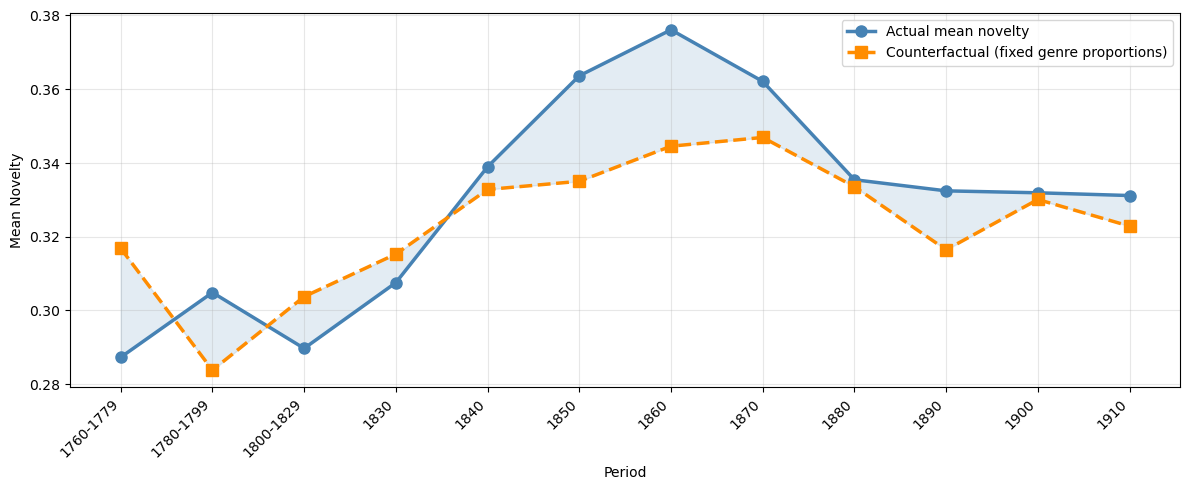

In [110]:
# plot: actual vs counterfactual novelty
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(period_order))
labels = [str(p) for p in period_order]

ax.plot(x, actual_novelty.values, marker='o', linewidth=2.5, markersize=8,
        color='steelblue', label='Actual mean novelty')
ax.plot(x, cf_series.values, marker='s', linewidth=2.5, markersize=8,
        linestyle='--', color='darkorange', label='Counterfactual (fixed genre proportions)')
ax.fill_between(x, actual_novelty.values, cf_series.values,
                alpha=0.15, color='steelblue')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_xlabel('Period')
ax.set_ylabel('Mean Novelty')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/genre_counterfactual.png', dpi=300, bbox_inches='tight')
plt.show()

## Reviewer 2

**Comparative corpora:** the British corpus (`data/british_titles.csv`, ~7900 titles, 1600–1850) is based on the dataset generously shared by Franco Moretti, used in his 2009 article on British novel titles. The French corpus (`data/french_titles.csv`, ~1030 titles, 1619–1900, 202 authors) was compiled from two sources: the CIDRE corpus of digitized French novels (369 titles, 1829–1900) and Wikidata SPARQL queries for works classified as novels or literary works by authors with occupation "novelist," filtered by genre metadata and deduplicated. The corpus has not been manually curated and may contain occasional non-novel titles; XVIII-century coverage is thin (~200 titles) due to Wikidata's sparse metadata for pre-1800 French literature. It is substantially smaller than the British and Russian corpora and skews toward canonical works, which should be kept in mind when interpreting proportions.

### Cross-national comparison: British, French, Russian title patterns

Comparison of title formulas and structural patterns across three national traditions.

In [111]:
brit = pd.read_csv("data/british_titles.csv")
fr = pd.read_csv("data/french_titles.csv")

brit = brit[['Year','Title','TitleLength']].dropna(subset=['Title'])
brit['Year'] = pd.to_numeric(brit['Year'], errors='coerce')
brit = brit.dropna(subset=['Year'])
brit['Year'] = brit['Year'].astype(int)

fr['TitleLength'] = fr['Title'].apply(lambda x: len(str(x).split()))
fr['Year'] = pd.to_numeric(fr['Year'], errors='coerce')
fr = fr.dropna(subset=['Year'])
fr['Year'] = fr['Year'].astype(int)

pd.set_option('display.max_colwidth', 120)

print(f"British: {len(brit)} titles, {brit.Year.min()}–{brit.Year.max()}")
print(f"French:  {len(fr)} titles, {fr.Year.min()}–{fr.Year.max()}")
print(f"Russian: {len(data)} titles, {int(data.year_begin.min())}–{int(data.year_begin.max())}")

British: 7913 titles, 1600–1850
French:  1029 titles, 1619–1900
Russian: 2029 titles, 1763–1917


#### 1. Title length shortening timeline

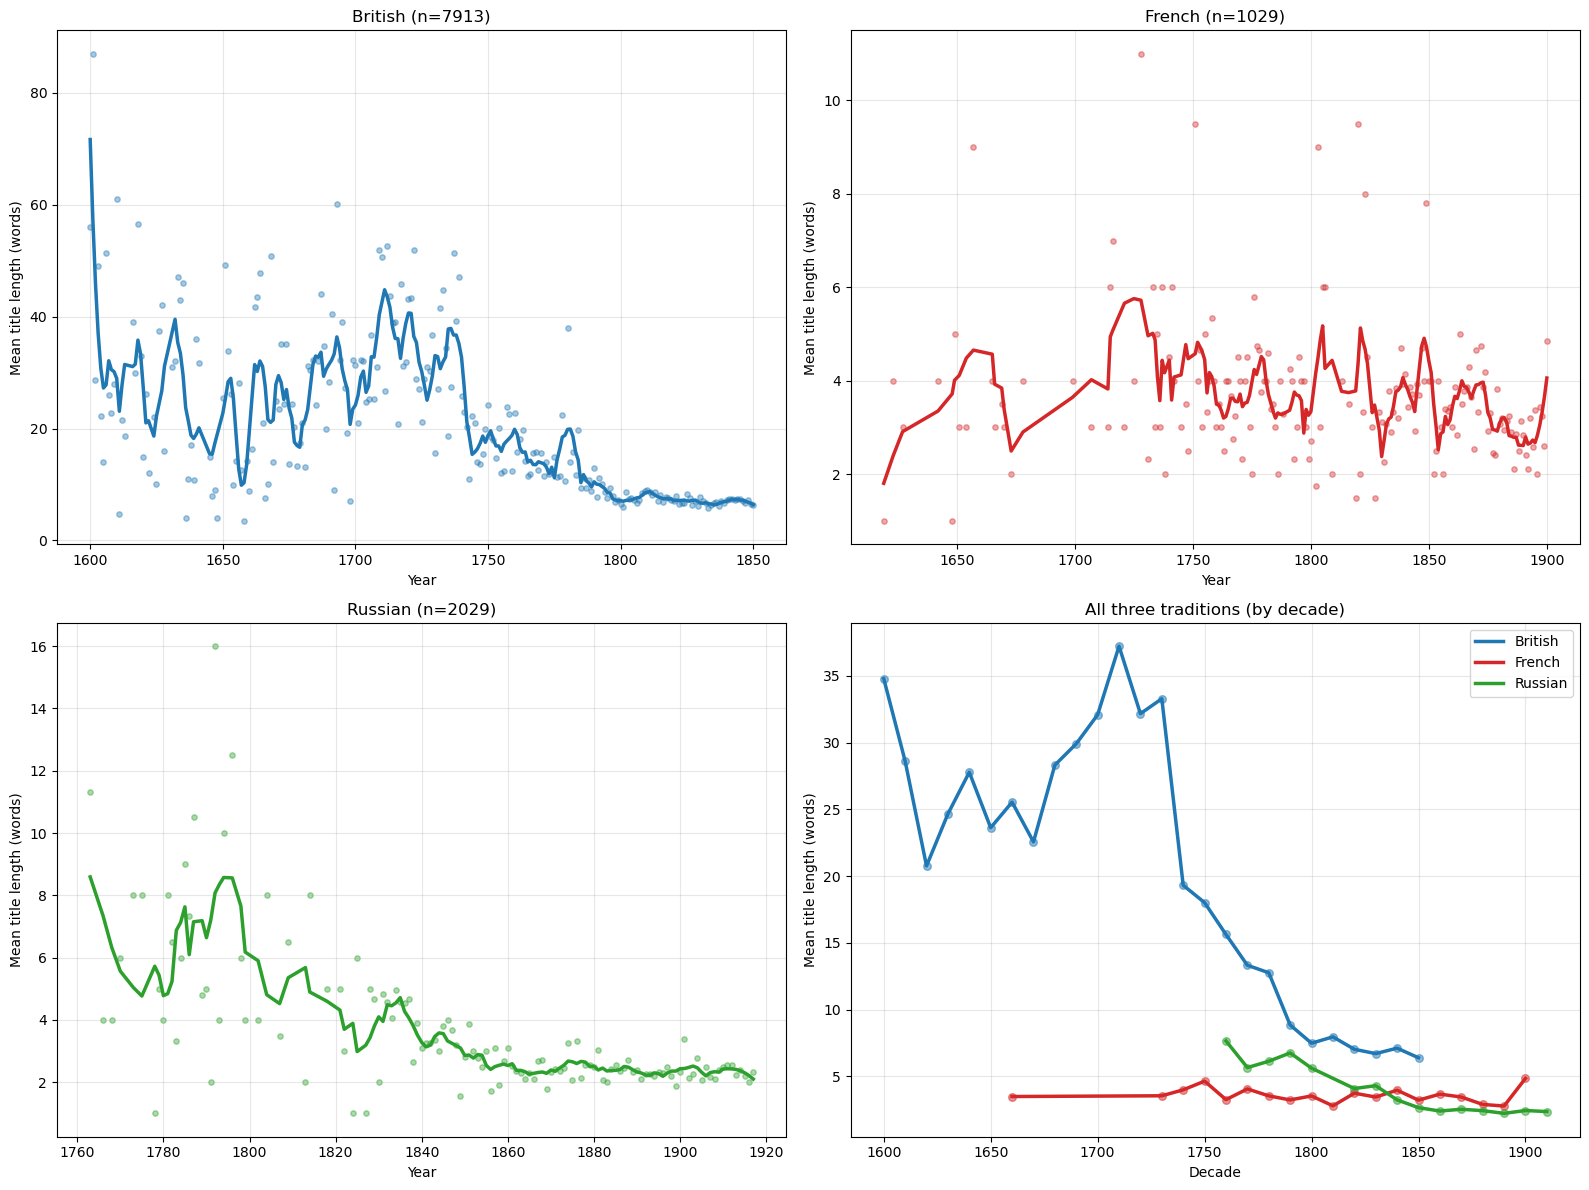

In [112]:
from scipy.signal import savgol_filter

brit['decade'] = (brit['Year'] // 10) * 10
fr['decade'] = (fr['Year'] // 10) * 10
rus_len = data.copy()
rus_len['decade'] = (rus_len['year_begin'] // 10) * 10
rus_len['TitleLength'] = rus_len['title'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

datasets = [
    ("British", brit, 'Year', '#1f77b4'),
    ("French", fr, 'Year', '#d62728'),
    ("Russian", rus_len, 'year_begin', '#2ca02c'),
]

for ax, (name, df, yr_col, col) in zip(axes.flatten()[:3], datasets):
    by_year = df.groupby(yr_col)['TitleLength'].mean().reset_index()
    by_year.columns = ['year', 'length']
    by_year = by_year.sort_values('year')
    wl = min(len(by_year) - 1, 11)
    if wl % 2 == 0: wl -= 1
    if wl >= 3:
        by_year['smoothed'] = savgol_filter(by_year['length'], window_length=wl, polyorder=2)
    else:
        by_year['smoothed'] = by_year['length']
    ax.scatter(by_year['year'], by_year['length'], color=col, s=15, alpha=0.4)
    ax.plot(by_year['year'], by_year['smoothed'], color=col, linewidth=2.5)
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean title length (words)')
    ax.set_title(f'{name} (n={len(df)})')
    ax.grid(True, alpha=0.3)

ax4 = axes.flatten()[3]
for name, df, yr_col, col in datasets:
    grp = df.groupby((df[yr_col]//10)*10)['TitleLength'].mean()
    counts = df.groupby((df[yr_col]//10)*10)['TitleLength'].count()
    grp = grp[counts >= 5]
    ax4.scatter(grp.index, grp.values, color=col, s=30, alpha=0.5)
    ax4.plot(grp.index, grp.values, color=col, label=name, linewidth=2.5, markersize=5)
ax4.set_xlabel('Decade')
ax4.set_ylabel('Mean title length (words)')
ax4.set_title('All three traditions (by decade)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 2. Double titles ("or" / "ou" / "или")

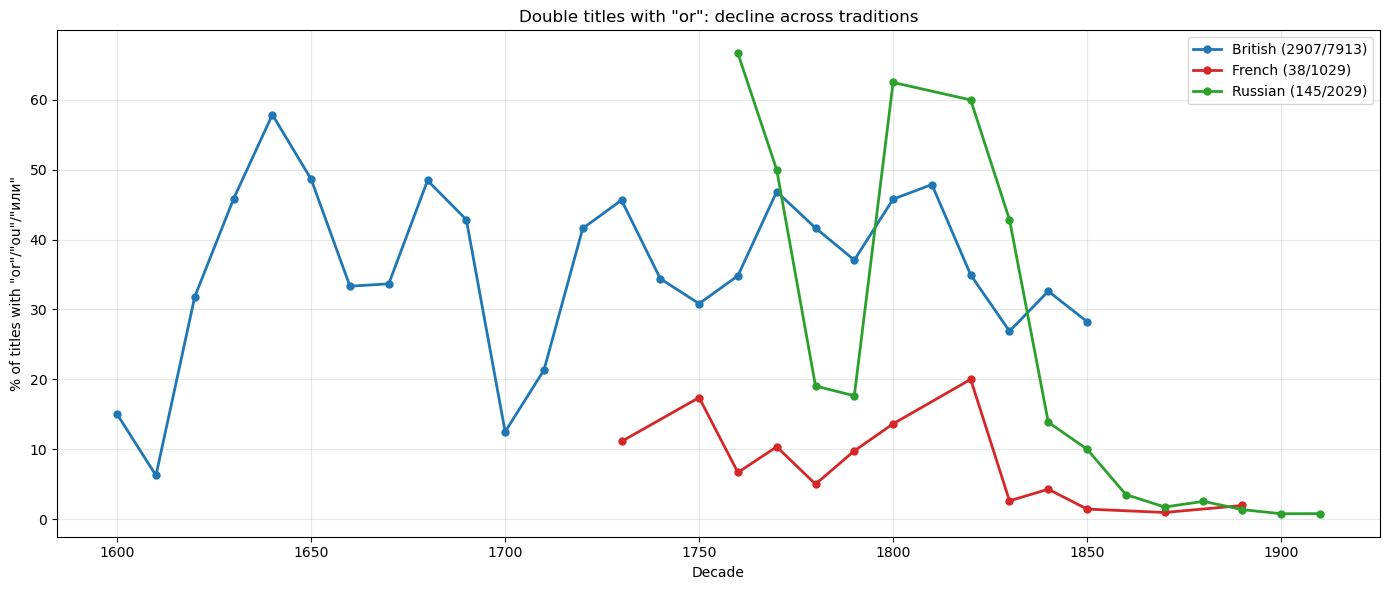

British 'or' titles (sample of 10):


,Year,Title
1637,1773,The Spiritual Quixote: Or The Summer's Ramble of Mr. Geoffrey Wildgoose. A Comic Romance.
1777,1779,"Shenstone-Green; Or, The New Paradise Lost. Being a History of Human Nature."
2312,1791,"The Cipher; or, the world as it goes."
2391,1792,"The Wandering Islander; or, The History of Mr. Charles North."
3083,1802,"Martin & Mansfeldt, or the Romance of Franconia."
3101,1802,"Correlia, or the Mystic Tomb."
4156,1817,"Rosabella; Or, A Mother's Marriage"
4329,1820,"Edward, or the Pursuit of Happiness"
5060,1828,"Tales of the Moors: or, Rainy Days in Ross-shire."
7371,1848,"The Young Countess; or, Love and Jealousy"



French 'ou' titles:


,Year,Title
5,1649,Artamène ou le Grand Cyrus
22,1716,L'Homère travesti ou L'Iliade en vers burlesques
26,1728,Les Aventures de Pomponius chevalier romain ou L'Histoire de notre temps
34,1737,"Pharsamon, ou les Nouvelles Folies romanesques"
49,1752,Narcisse ou l'Amant de lui-même
51,1753,"Naufrage des isles flottantes, ou Basiliade du célèbre Pilpai"
58,1756,Sophie ou mémoires intéressans
68,1759,"Candide, ou l'Optimisme"
73,1761,Julie ou la Nouvelle Héloïse
75,1762,Émile ou De l'éducation



Russian 'или' titles (first 15):


,year_begin,title
0,1763,"Награждённая постоянность, или Приключения Лизарка и Сарманды"
1,1763,"Непостоянная фортуна, или Похождения Мирамонда"
3,1766,"Пересмешник, или Славенские сказки"
5,1768,"Нума, или процветающий Рим"
6,1770,"Пригожая повариха, или Похождение развратной женщины"
7,1770,"Славянские древности, или Приключения славянских князей"
9,1775,"Несчастный Никанор, или Приключение жизни российского дворянина Н********"
19,1784,"Лейнард и Термилия, или Злосчастная судьба даух любовников"
24,1786,"Лабиринт волшебства, или Удивительные приключения востояных принцев"
28,1789,"Торжествующая добродетель, или Жизнь и приключения гонимого фортуною Селима"


In [113]:
brit_or = brit[brit['Title'].str.contains(r',?\s+or[,:;\s]', case=False, na=False)]
fr_ou = fr[fr['Title'].str.contains(r',?\s+ou[,:;\s]', case=False, na=False)]
rus_ili = data[data['title'].str.contains(r',?\s+или\s', case=False, na=False)]

fig, ax = plt.subplots(figsize=(14, 6))
for name, subset, total_df, yr_col, col in [
    ("British", brit_or, brit, 'Year', '#1f77b4'),
    ("French", fr_ou, fr, 'Year', '#d62728'),
    ("Russian", rus_ili, data, 'year_begin', '#2ca02c')]:
    sub_dec = subset.assign(decade=(subset[yr_col] // 10) * 10).groupby('decade').size()
    tot_dec = total_df.assign(decade=(total_df[yr_col] // 10) * 10).groupby('decade').size()
    pct = (sub_dec / tot_dec * 100).dropna()
    pct = pct[tot_dec.reindex(pct.index) >= 5]
    ax.plot(pct.index, pct.values, marker='o', label=f"{name} ({len(subset)}/{len(total_df)})",
            color=col, linewidth=2, markersize=5)

ax.set_xlabel('Decade')
ax.set_ylabel('% of titles with "or"/"ou"/"или"')
ax.set_title('Double titles with "or": decline across traditions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("British 'or' titles (sample of 10):")
display(brit_or[['Year','Title']].sort_values('Year').sample(10, random_state=42).sort_values('Year'))
print("\nFrench 'ou' titles:")
display(fr_ou[['Year','Title']].sort_values('Year'))
print("\nRussian 'или' titles (first 15):")
display(rus_ili[['year_begin','title']].sort_values('year_begin').head(15))

#### 3. Single-word anthroponymic titles

French single-name titles (Armance 1827, Indiana 1831, Gobseck 1830) appear roughly synchronous with Russian ones (Roslavlev 1836, Dubrovsky 1841), suggesting continued European influence in the 1830–1860 period. The French corpus may overrepresent short canonical titles due to its Wikidata provenance.

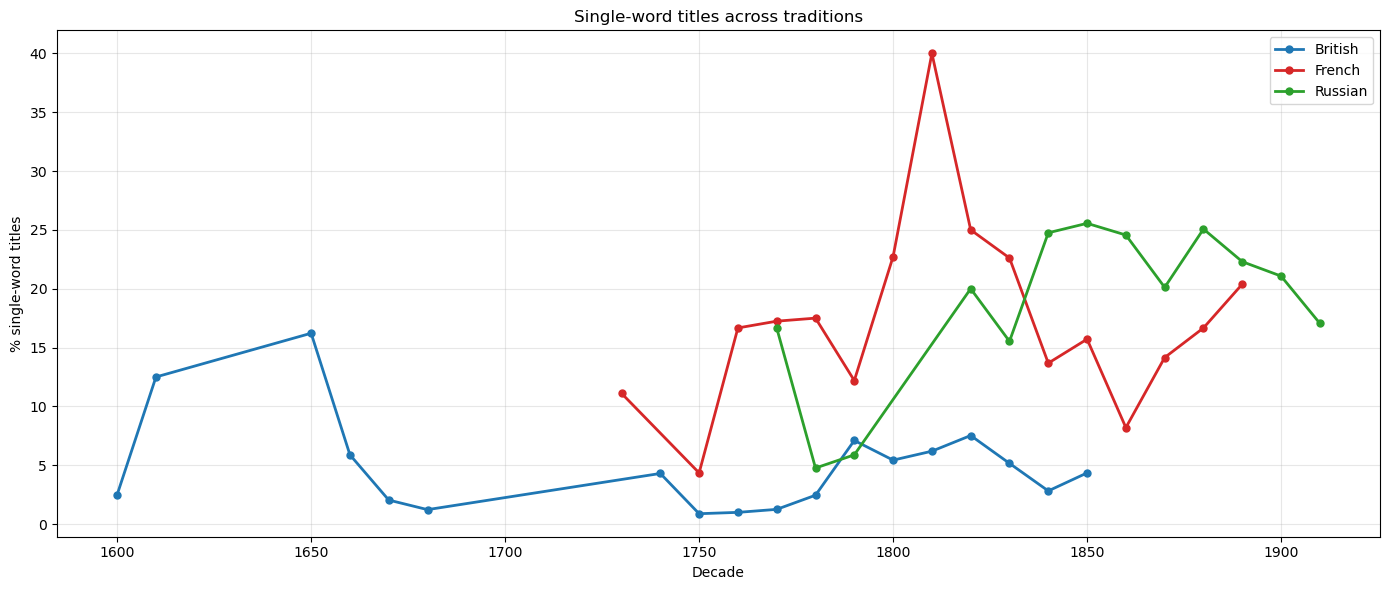

British single-word titles (pre-1830, sample):


,Year,Title
4794,1825,Burton
4881,1826,Granby
4877,1826,Almack's
4876,1826,Reflection
4872,1826,Obstinacy
4853,1826,Truth
4862,1826,Edward
4924,1827,Falkland
4927,1827,Flirtation
4947,1827,Self-Denial



French single-word titles (pre-1840):


,Year,Title,Author
0,1619,Polexandre,Marin Le Roy de Gomberville
4,1648,Polyandre,Charles Sorel
27,1731,Cleveland,Abbé Prévost
53,1753,Amilec,Charles-François Tiphaigne de La Roche
71,1760,Giphantie,Charles-François Tiphaigne de La Roche
...,...,...,...
343,1837,Emmeline,Alfred de Musset
347,1838,L’Uscoque,George Sand
352,1838,Latréaumont,Eugène Sue
364,1839,Béatrix,Honoré de Balzac



Russian single-word titles:


,year_begin,title,author
10,1778,Небылица,"Веревкин, Михаил Иванович"
23,1786,Роза,"Эмин, Николай Федорович"
40,1793,Арфаксад,"Захарьин, Петр Михайлович"
63,1824,Бурсак,"Нарежный, Василий Трофимович"
66,1827,Гайдамак,"Сомов, Орест Михайлович"
...,...,...,...
1997,1916,Ведьма,"Беляев, Юрий Дмитриевич"
2020,1917,Игра,"Ленский, Владимир Яковлевич"
2025,1917,Добыча,"Тыркова, Ариандна Владимировна"
2017,1917,Ветер,"Слёзкин, Юрий Львович"


In [114]:
rus_1w = data[data['title'].apply(lambda x: len(str(x).split())) == 1]
brit_1w = brit[brit['TitleLength'] == 1]
fr_1w = fr[fr['TitleLength'] == 1]

fig, ax = plt.subplots(figsize=(14, 6))
for name, subset, total_df, yr_col, col in [
    ("British", brit_1w, brit, 'Year', '#1f77b4'),
    ("French", fr_1w, fr, 'Year', '#d62728'),
    ("Russian", rus_1w, data, 'year_begin', '#2ca02c')]:
    sub_dec = subset.assign(decade=(subset[yr_col] // 10) * 10).groupby('decade').size()
    tot_dec = total_df.assign(decade=(total_df[yr_col] // 10) * 10).groupby('decade').size()
    pct = (sub_dec / tot_dec * 100).dropna()
    pct = pct[tot_dec.reindex(pct.index) >= 5]
    ax.plot(pct.index, pct.values, marker='o', label=name, color=col, linewidth=2, markersize=5)

ax.set_xlabel('Decade')
ax.set_ylabel('% single-word titles')
ax.set_title('Single-word titles across traditions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("British single-word titles (pre-1830, sample):")
display(brit_1w[brit_1w['Year'] < 1830][['Year','Title']].sort_values('Year').tail(20))
print("\nFrench single-word titles (pre-1840):")
fr_names = fr_1w[fr_1w['Year'] < 1840]
display(fr_names[['Year','Title','Author']].sort_values('Year'))
print("\nRussian single-word titles:")
display(rus_1w[['year_begin','title','author']].sort_values('year_begin'))

#### 4. Oppositional titles "X and Y" / "X et Y" / "X и Y"

The pattern appears in all three traditions. Notably, the British corpus contains "Fathers and Sons" (1842), two decades before Turgenev (1862), alongside Sense and Sensibility (1811) and Pride and Prejudice (1813).

In [115]:
brit_opp = brit[brit['Title'].str.match(r'^[A-Z]\w+\s+and\s+[A-Z]\w+$', case=False, na=False)]
fr_et = fr[fr['Title'].str.contains(r'\bet\b', case=False, na=False) & (fr['TitleLength'] <= 4)]
rus_conj = data[data['POS_title'] == 'NOUN CONJ NOUN']

print(f"British strict 'X and Y': {len(brit_opp)}")
print(f"French short 'X et Y' (≤4 words): {len(fr_et)}")
print(f"Russian NOUN CONJ NOUN: {len(rus_conj)}")

print("\nBritish 1800–1850:")
display(brit_opp[(brit_opp['Year'] >= 1800) & (brit_opp['Year'] <= 1850)][['Year','Title']].sort_values('Year'))

print("\nFrench:")
display(fr_et[['Year','Title']].sort_values('Year'))

print("\nRussian:")
display(rus_conj[['year_begin','title']].sort_values('year_begin'))

British strict 'X and Y': 88
French short 'X et Y' (≤4 words): 20
Russian NOUN CONJ NOUN: 59

British 1800–1850:


,Year,Title
3002,1801,Truth and Fiction
3135,1803,Light and Shade
3155,1803,Ariana and Maud
3273,1805,Men and Women
3302,1805,Herman and Emilia
...,...,...
7677,1849,Tales and Trifles
7752,1850,Shadows and Sunshine
7753,1850,Sin and Sorrow
7751,1850,Royalists and Roundheads



French:


,Year,Title
97,1768,Iphis et Aglaè
139,1782,Adèle et Théodore
141,1783,Arsace et Isménie
149,1784,Bergeries et opuscules
159,1787,Paul et Virginie
162,1788,Observations et conjectures politiques
165,1788,L'Honneur perdu et recouvré
175,1793,Aline et Valcour
204,1799,Angélique et Jeanneton
202,1799,Emilie et Alphonse



Russian:


,year_begin,title
32,1789,Кадм и Гармония
44,1796,Пламир и Раида
52,1807,Всеволод и Велеслава
62,1822,"Аристион, или Перевоспитание"
161,1836,Страсть и мщение
206,1838,Сердце и думка
259,1842,Альф и Альдона
350,1852,Брат и сестра
427,1860,Труд и капитал
440,1861,Грязь и золото


#### 5. Prepositional titles

Very few analogues found in British (3) or French (9) traditions, compared to 271 in the Russian corpus. This appears to support the article's claim about prepositional titles as a distinctively Russian development, though the difference in corpus chronologies (British data ends in 1850) should be noted.

In [116]:
brit_prep = brit[brit['Title'].str.match(
    r'^(At|In|On|Out|Under|Over|From|To|Through|Beyond|Before|After|Between)\b', case=True, na=False)]
fr_prep = fr[fr['Title'].str.match(
    r'^(À|Au|Aux|En|Sur|Sous|Dans|De|Du|Des|Par|Entre|Vers|Devant|Après|Avant)\b', case=True, na=False)]
rus_prep = data[data['POS_title'].str.startswith('PREP', na=False)]

print(f"Prepositional titles: British={len(brit_prep)}, French={len(fr_prep)}, Russian={len(rus_prep)}")

print("\nBritish:")
display(brit_prep[['Year','Title']].sort_values('Year'))

print("\nFrench:")
display(fr_prep[['Year','Title']].sort_values('Year'))

print("\nRussian prepositional titles by decade:")
rus_prep_dec = rus_prep.assign(decade=(rus_prep['year_begin']//10)*10).groupby('decade').size()
print(rus_prep_dec.to_string())

print("\nRussian prepositional titles (sample of 15):")
display(rus_prep[['year_begin','title']].sort_values('year_begin').sample(15, random_state=42).sort_values('year_begin'))

Prepositional titles: British=3, French=15, Russian=271

British:


,Year,Title
5011,1828,At Home
7294,1847,From Oxford to Rome: And How it Fared with some who lately Made the Journey. By a Companion Traveller
7546,1849,Before and After



French:


,Year,Title
283,1832,À quoi rêvent les jeunes filles
353,1838,Sur la naissance du Comte de Paris
380,1840,À la mi-Carême
406,1842,Après une lecture
512,1855,Au bord de l'Adour
558,1859,Au coin du feu
605,1865,De la Terre à la Lune
689,1871,Après la pluie le beau temps
744,1877,À travers champs
839,1883,Au Bonheur des Dames



Russian prepositional titles by decade:
decade
1850     2
1860    12
1870    34
1880    54
1890    73
1900    51
1910    45

Russian prepositional titles (sample of 15):


,year_begin,title
622,1874,С севера на юг
687,1879,На высоте и на доле
961,1887,"По локоть в золоте, по локоть в крови"
959,1887,Из прошлого
1202,1892,На берегах Невы и Темзы
1244,1893,Под неотразимой десницей
1298,1895,В боевых трудах и на покое
1408,1897,Из далекого прошлого
1453,1898,"За Богом молитва, за царем служба не пропадают"
1571,1901,На изломе


#### 6. Interrogative and exclamatory titles

No genuine interrogative novel titles found in British or French corpora. Russian examples — Кто виноват? (Who Is to Blame?, 1847), Что делать? (What Is to Be Done?, 1863), Где лучше? (Where Is It Better?, 1868) — appear to be a distinctive development, likely tied to the politicization of Russian literature in the 1840s–1860s.

In [117]:
rus_q = data[data['title'].str.contains(r'\?', na=False)]
brit_q_genuine = brit[brit['Title'].str.match(r'^(Who|What|Where|When|Why|How|Is|Are|Was|Will|Do|Does|Shall|Can)\b', 
                                               case=True, na=False)]
fr_q = fr[fr['Title'].str.match(r'^(Qui|Que|Où|Quand|Comment|Pourquoi|Est-ce)\b', case=True, na=False)]

print(f"Genuine interrogative titles: British={len(brit_q_genuine)}, French={len(fr_q)}, Russian={len(rus_q)}")

print("\nBritish genuine interrogative:")
display(brit_q_genuine[['Year','Title']].sort_values('Year'))

print("\nFrench genuine interrogative:")
display(fr_q[['Year','Title']].sort_values('Year'))

print("\nRussian interrogative:")
display(rus_q[['year_begin','title']].sort_values('year_begin'))

brit_excl = brit[brit['Title'].str.contains(r'!', na=False)]
fr_excl = fr[fr['Title'].str.contains(r'!', na=False)]
rus_excl = data[data['title'].str.contains(r'!', na=False)]
print(f"\nExclamatory titles: British={len(brit_excl)}, French={len(fr_excl)}, Russian={len(rus_excl)}")

print("\nBritish exclamatory:")
display(brit_excl[['Year','Title']].sort_values('Year'))

print("\nFrench exclamatory:")
display(fr_excl[['Year','Title']].sort_values('Year'))

print("\nRussian exclamatory:")
display(rus_excl[['year_begin','title']].sort_values('year_begin'))

Genuine interrogative titles: British=12, French=1, Russian=19

British genuine interrogative:


,Year,Title
1783,1780,"How She Lost Him; Or, the history of Miss Wyndham."
2987,1801,What Has Been
3102,1802,Who's the Murderer? or The mystery of the forest.
3195,1804,"What you Please or, Memoirs of Modern characters"
3230,1804,"Can We Doubt It? Or, the genuine history of two families of Norwich."
3676,1810,"Who Can He Be, or, Who is his Father?"
4507,1822,Who is the Bridegroom? Or Nuptial Discoveries
4616,1823,"What Shall Be, Shall Be"
4630,1823,"How to be Rid of a Wife, and The Lily of Annandale"
6166,1840,Who Shall be Heir?



French genuine interrogative:


,Year,Title
927,1890,Qui sait ?



Russian interrogative:


...

,Year,Title
2584,1796,The Castle of Inchvally: a tale---alas! Too true.
2589,1796,Joan!!!
2768,1798,More Ghosts! By the wife of an officer
3043,1801,"The Romance of Smyrna; or, the prediction fulfilled!!!"
3079,1802,"Odd Enough, to be sure! or, Emilius in the world."
3080,1802,Astonishment!!! A romance of a century ago.
3137,1803,"Three Monks, The!!!"
3148,1803,"Very Strange, but Very True! or, The History of an Old Man's Young Wife"
3180,1803,"Belgrove Castle; or, the horrid spectre!"
3233,1804,Something Odd!



French exclamatory:


,Year,Title
54,1754,Ah! quel conte!
452,1845,Il était temps ! ou À quelque chose malheur est bon
628,1866,Quel amour d’enfant !



Russian exclamatory:


,year_begin,title
81,1831,Удивительный человек!
295,1846,"Юмористические рассказы нашего времени, издаваемые Абракадаброю. Вот тебе и Марья Петровна! или Занимательные похожд..."
453,1862,В путь-дорогу!
809,1883,Вперед!
817,1883,За Урал!
1237,1893,Добей его! (Pollice verso)
1243,1893,Сим победиши!
1347,1896,Свету больше!
1780,1910,Проснулась женщина!
1814,1911,Руки вверх!


#### 7. "The X of Y" / "Le X de Y" — pan-European genitive formula

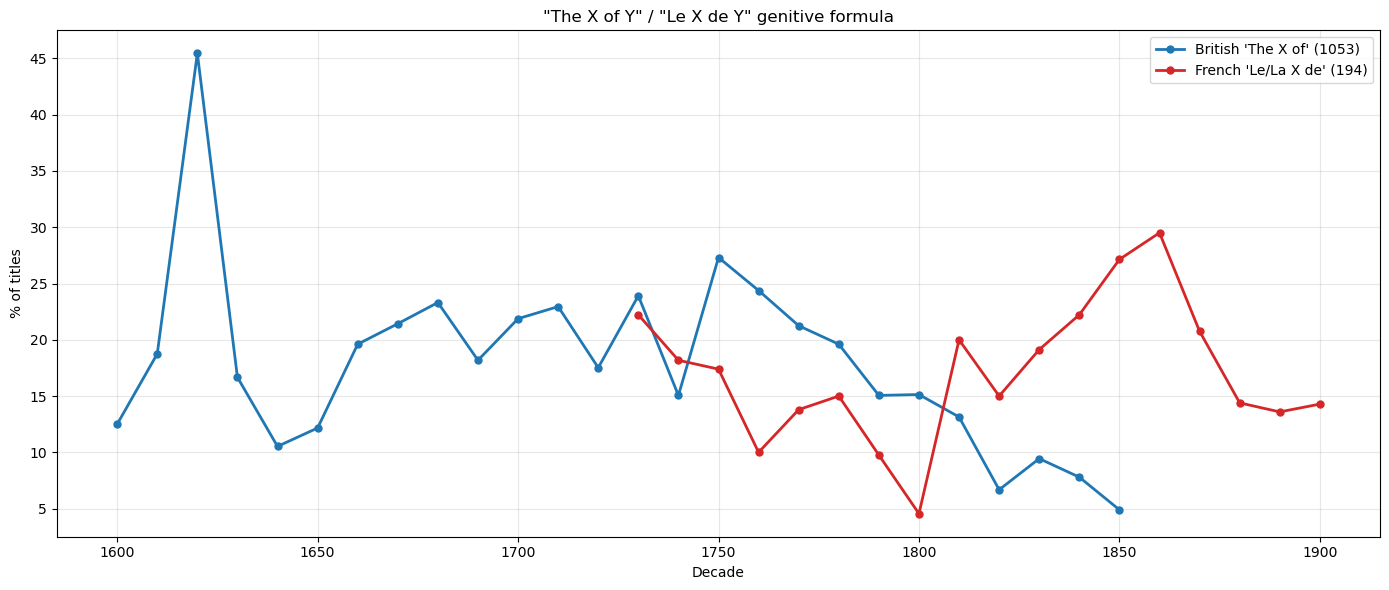

British 'The X of': 1053/7913 = 13.3%
French 'Le/La X de': 194/1029 = 18.9%

British 'The X of' (sample of 15):


,Year,Title
183,1657,"The life of a satyrical puppy, called Nim? Who worrieth all those satyrists he knowes, and barkes at the rest."
323,1678,The triumph of love over fortune
488,1688,The disorders of Bassett
701,1719,"The Memoirs of Majr Alexander Ramkins, A Highland Oficer, Now in Prison at Avignon. Being an Account of several rema..."
1225,1758,The Adventures of a Turk
1438,1769,The History of Amintor and Teresa.
1526,1771,The History of Mr. Cecil and Miss Gray
1868,1783,"The Woman of Letters; Or, the history of Miss Fanny Belton."
2254,1790,"The Letters of Maria; to which is added, an account of her death."
2437,1793,"The Advantages of Education, Or the History of Maria Williams, A tale for misses and their mammas."



French 'Le/La X de' (sample of 15):


,Year,Title
52,1753,La Jardinière de Vincennes
98,1769,Lettres de lord Austin de N**
102,1771,Le Marquis de T***
121,1777,Lettres de Fanni Butler à Milord Charles Alfred de Caitombridge
365,1839,L'abbesse de Castro
447,1845,La Croix de Berny
485,1849,Les Mystères du Peuple ou Histoire d'une famille de prolétaires à travers les âges
538,1858,Le chercheur de pistes
590,1863,Les Chevaliers du clair de lune I
596,1863,L'Auberge de l'Ange-Gardien


In [118]:
brit_of = brit[brit['Title'].str.match(r'^The\s+\w+\s+of\s+', case=False, na=False)]
fr_de = fr[fr['Title'].str.match(r'^(Le|La|Les|L\')\s*\w+\s+(de|du|des|d\')\s+', case=False, na=False)]

fig, ax = plt.subplots(figsize=(14, 6))
for name, subset, total_df, yr_col, col in [
    ("British 'The X of'", brit_of, brit, 'Year', '#1f77b4'),
    ("French 'Le/La X de'", fr_de, fr, 'Year', '#d62728')]:
    sub_dec = subset.assign(decade=(subset[yr_col] // 10) * 10).groupby('decade').size()
    tot_dec = total_df.assign(decade=(total_df[yr_col] // 10) * 10).groupby('decade').size()
    pct = (sub_dec / tot_dec * 100).dropna()
    pct = pct[tot_dec.reindex(pct.index) >= 5]
    ax.plot(pct.index, pct.values, marker='o', label=f"{name} ({len(subset)})",
            color=col, linewidth=2, markersize=5)

ax.set_xlabel('Decade')
ax.set_ylabel('% of titles')
ax.set_title('"The X of Y" / "Le X de Y" genitive formula')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"British 'The X of': {len(brit_of)}/{len(brit)} = {len(brit_of)/len(brit)*100:.1f}%")
print(f"French 'Le/La X de': {len(fr_de)}/{len(fr)} = {len(fr_de)/len(fr)*100:.1f}%")

print("\nBritish 'The X of' (sample of 15):")
display(brit_of[['Year','Title']].sort_values('Year').sample(15, random_state=42).sort_values('Year'))

print("\nFrench 'Le/La X de' (sample of 15):")
display(fr_de[['Year','Title']].sort_values('Year').sample(15, random_state=42).sort_values('Year'))

#### 8. Annotative formulas: "life" / "adventures" / "history" / "mémoires"

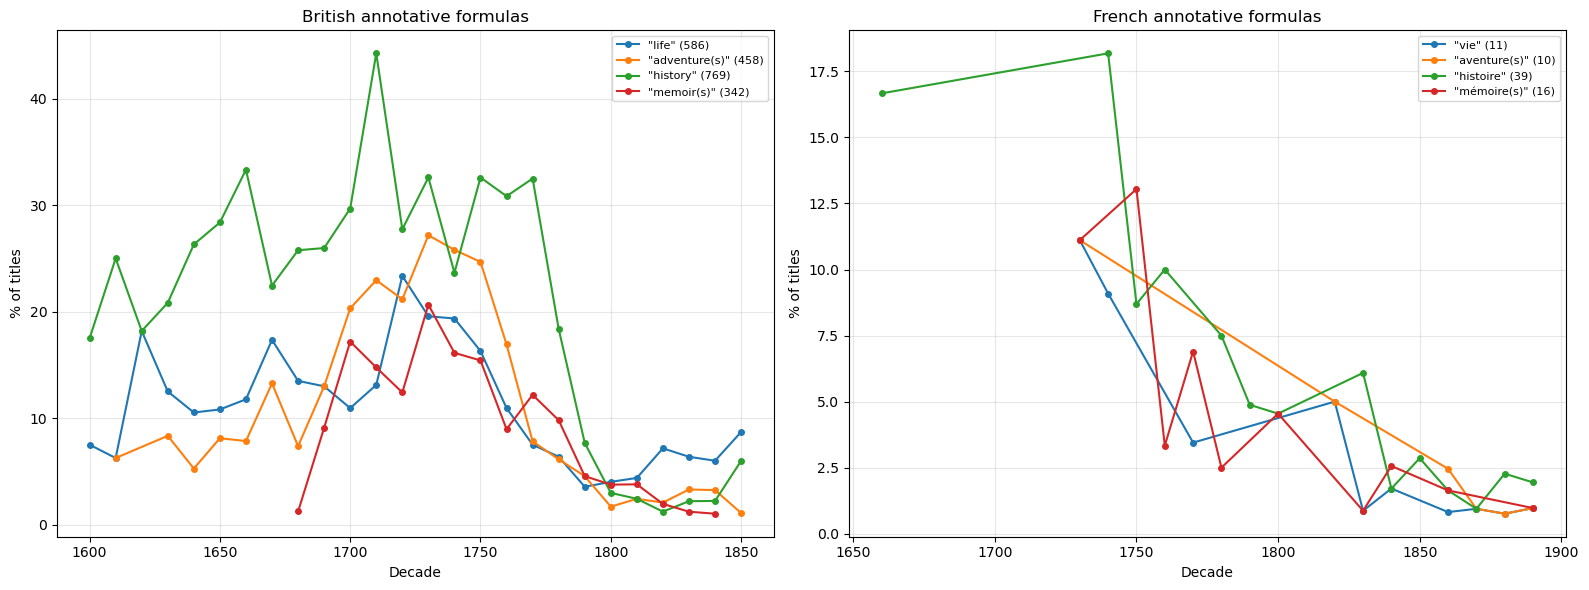

In [119]:
formulas = {
    'British': [
        ('life', r'\blife\b'), ('adventure(s)', r'\badventures?\b'),
        ('history', r'\bhistory\b'), ('memoir(s)', r'\bmemoirs?\b')],
    'French': [
        ('vie', r'\bvie\b'), ('aventure(s)', r'\baventures?\b'),
        ('histoire', r'\bhistoire\b'), ('mémoire(s)', r'\bmémoires?\b')]
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (corpus_name, pats) in zip(axes, formulas.items()):
    df = brit if corpus_name == 'British' else fr
    for label, pat in pats:
        matches = df[df['Title'].str.contains(pat, case=False, na=False)]
        sub_dec = matches.assign(decade=(matches['Year']//10)*10).groupby('decade').size()
        tot_dec = df.assign(decade=(df['Year']//10)*10).groupby('decade').size()
        pct = (sub_dec / tot_dec * 100).dropna()
        pct = pct[tot_dec.reindex(pct.index) >= 5]
        if len(pct) > 0:
            ax.plot(pct.index, pct.values, marker='o', label=f'"{label}" ({len(matches)})',
                    linewidth=1.5, markersize=4)
    ax.set_title(f'{corpus_name} annotative formulas')
    ax.set_xlabel('Decade')
    ax.set_ylabel('% of titles')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 9. Titles with historical dates and centuries

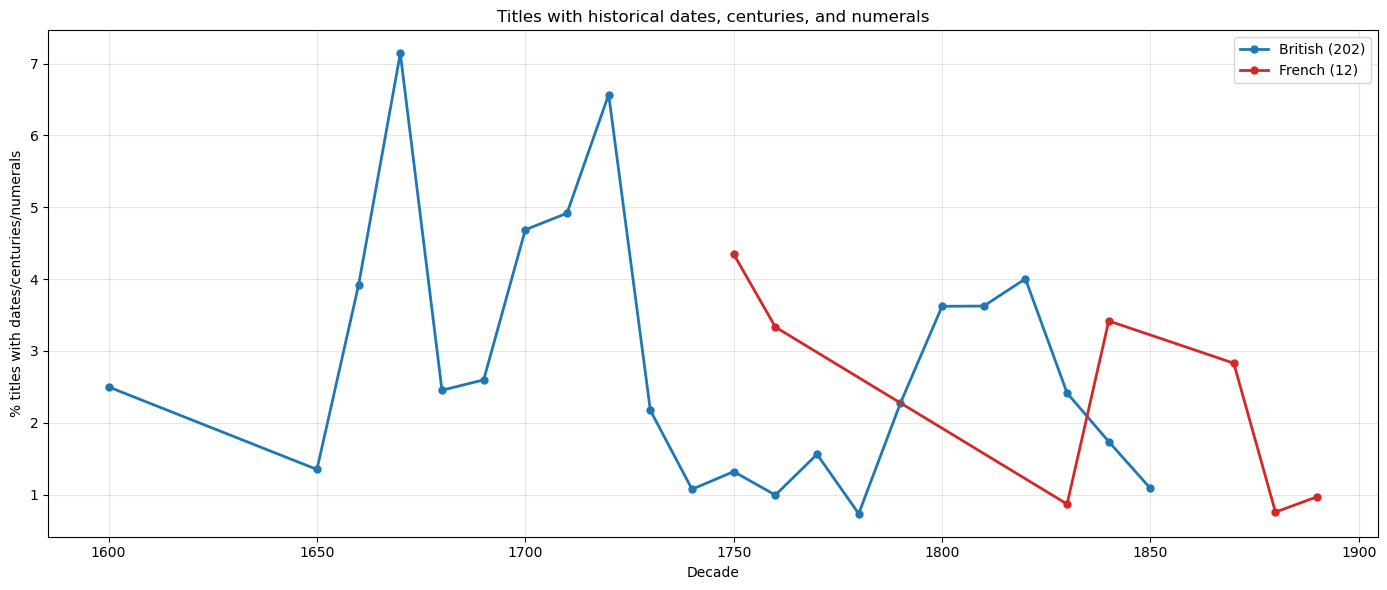

French with dates/centuries/numerals:


,Year,Title
48,1751,Mémoires pour servir à l’histoire des mœurs du XVIII. siècle
88,1766,Le mariage du siècle
325,1836,La Confession d'un enfant du siècle
407,1842,La Mille et Deuxième Nuit
432,1844,Les Trois Mousquetaires
435,1844,Louis XIV et son siècle
487,1849,Les mille et un fantômes : Une journée à Fontenay-aux-Roses
686,1870,Vingt mille lieues sous les mers
704,1873,Le Tour du monde en quatre-vingts jours
760,1878,Un capitaine de quinze ans


In [120]:
brit_num = brit[brit['Title'].str.contains(r'\b1[3-9]\d{2}\b|\b\d+th\b|\bcentury\b', case=False, na=False)]
fr_num = fr[fr['Title'].str.contains(
    r'\b1[3-9]\d{2}\b|\b2000\b|\bsiècle\b|\bXIV|XV[^a-z]|XVI|XVII|XVIII|XIX'
    r'|\bquinze ans\b|\bquatre-vingt|\bvingt mille\b|\bmille et\b|\btrois mousq',
    case=False, na=False)]

fig, ax = plt.subplots(figsize=(14, 6))
for name, subset, total_df, yr_col, col in [
    ("British", brit_num, brit, 'Year', '#1f77b4'),
    ("French", fr_num, fr, 'Year', '#d62728')]:
    sub_dec = subset.assign(decade=(subset[yr_col] // 10) * 10).groupby('decade').size()
    tot_dec = total_df.assign(decade=(total_df[yr_col] // 10) * 10).groupby('decade').size()
    pct = (sub_dec / tot_dec * 100).dropna()
    pct = pct[tot_dec.reindex(pct.index) >= 10]
    ax.plot(pct.index, pct.values, marker='o', label=f"{name} ({len(subset)})",
            color=col, linewidth=2, markersize=5)

ax.set_xlabel('Decade')
ax.set_ylabel('% titles with dates/centuries/numerals')
ax.set_title('Titles with historical dates, centuries, and numerals')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("French with dates/centuries/numerals:")
display(fr_num[['Year','Title']].sort_values('Year'))

#### 10. Short titles (≤2 words) share over time

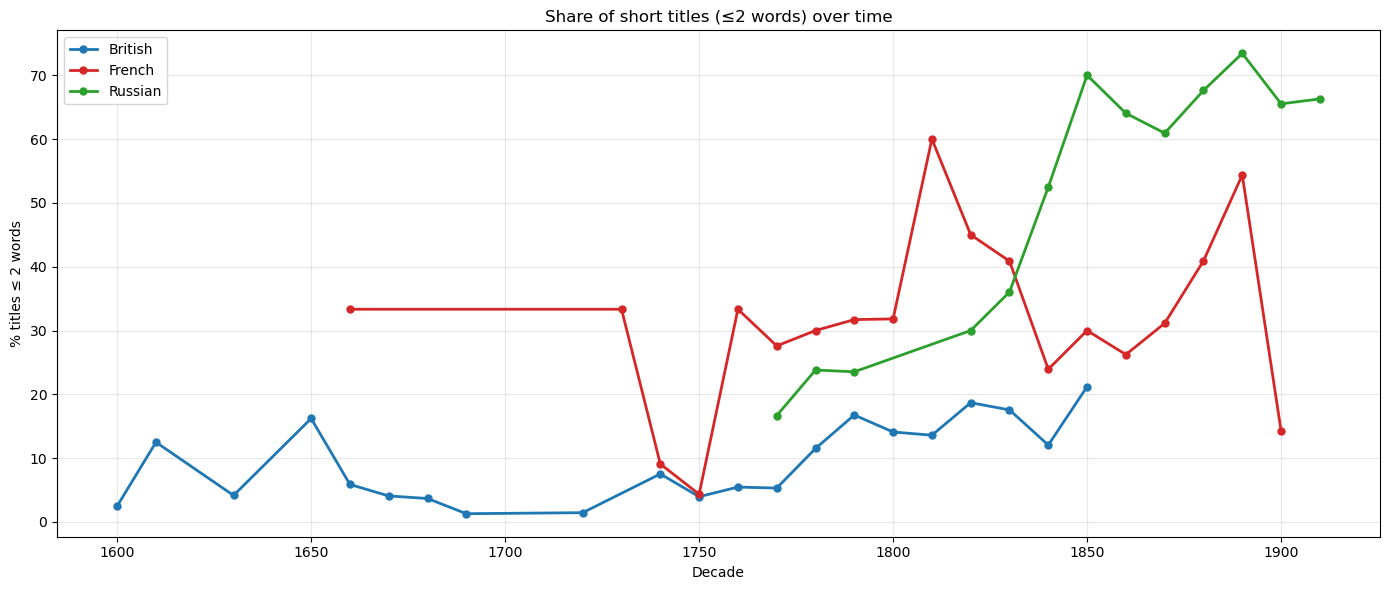

In [121]:
fig, ax = plt.subplots(figsize=(14, 6))
for name, df, yr_col, col in [("British", brit, 'Year', '#1f77b4'),
                                ("French", fr, 'Year', '#d62728'),
                                ("Russian", rus_len, 'year_begin', '#2ca02c')]:
    df_dec = df.assign(decade=(df[yr_col] // 10) * 10)
    short = df_dec[df_dec['TitleLength'] <= 2]
    total_by_dec = df_dec.groupby('decade').size()
    short_by_dec = short.groupby('decade').size()
    pct = (short_by_dec / total_by_dec * 100).dropna()
    pct = pct[total_by_dec.reindex(pct.index) >= 5]
    ax.plot(pct.index, pct.values, marker='o', label=name, color=col, linewidth=2, markersize=5)

ax.set_xlabel('Decade')
ax.set_ylabel('% titles ≤ 2 words')
ax.set_title('Share of short titles (≤2 words) over time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Echo effect: scale of title recycling

In [122]:
# max cosine similarity of each title to all earlier titles, split by period
from scipy.spatial.distance import cdist

data["emb"] = data["title"].map(title_to_embedding)
has_emb = data.dropna(subset=["emb"])

early = has_emb[has_emb["year_begin"] < 1870]
late = has_emb[has_emb["year_begin"] >= 1870]

early_embs = np.stack(early["emb"].values)
late_embs = np.stack(late["emb"].values)
sim_late = 1 - cdist(late_embs, early_embs, metric="cosine")
max_sim_late = sim_late.max(axis=1)

pre1830 = has_emb[has_emb["year_begin"] < 1830]
mid = has_emb[(has_emb["year_begin"] >= 1830) & (has_emb["year_begin"] < 1870)]
pre_embs = np.stack(pre1830["emb"].values)
mid_embs = np.stack(mid["emb"].values)
sim_mid = 1 - cdist(mid_embs, pre_embs, metric="cosine")
max_sim_mid = sim_mid.max(axis=1)

rows = []
for label, sims in [("1830–1869 vs <1830", max_sim_mid), ("1870–1917 vs <1870", max_sim_late)]:
    rows.append({
        "period": label, "n": len(sims),
        "mean": f"{sims.mean():.3f}", "median": f"{np.median(sims):.3f}",
        "≥0.7": f"{(sims>=0.7).sum()} ({(sims>=0.7).mean()*100:.1f}%)",
        "≥0.8": f"{(sims>=0.8).sum()} ({(sims>=0.8).mean()*100:.1f}%)",
        "≥0.9": f"{(sims>=0.9).sum()} ({(sims>=0.9).mean()*100:.1f}%)",
    })
print(pd.DataFrame(rows).to_string(index=False))

            period    n  mean median         ≥0.7        ≥0.8      ≥0.9
1830–1869 vs <1830  466 0.672  0.676  188 (40.3%)   37 (7.9%)  1 (0.2%)
1870–1917 vs <1870 1492 0.744  0.746 1084 (72.7%) 357 (23.9%) 44 (2.9%)


In [123]:
# breakdown by decade
late_df = late.copy()
late_df["max_sim"] = max_sim_late
late_df["decade"] = (late_df["year_begin"] // 10) * 10

mid_df = mid.copy()
mid_df["max_sim"] = max_sim_mid
mid_df["decade"] = (mid_df["year_begin"] // 10) * 10

rows = []
for dec in [1830, 1840, 1850, 1860]:
    s = mid_df[mid_df["decade"] == dec]
    rows.append({"decade": f"{dec}s", "n": len(s), "mean": f"{s['max_sim'].mean():.3f}",
                 "≥0.8": f"{(s['max_sim']>=0.8).sum()} ({(s['max_sim']>=0.8).mean()*100:.1f}%)"})
for dec in [1870, 1880, 1890, 1900, 1910]:
    s = late_df[late_df["decade"] == dec]
    rows.append({"decade": f"{dec}s", "n": len(s), "mean": f"{s['max_sim'].mean():.3f}",
                 "≥0.8": f"{(s['max_sim']>=0.8).sum()} ({(s['max_sim']>=0.8).mean()*100:.1f}%)"})
print(pd.DataFrame(rows).to_string(index=False))

decade   n  mean        ≥0.8
 1830s 161 0.715  19 (11.8%)
 1840s 101 0.684    9 (8.9%)
 1850s  90 0.646    4 (4.4%)
 1860s 114 0.619    5 (4.4%)
 1870s 174 0.739  42 (24.1%)
 1880s 355 0.752 104 (29.3%)
 1890s 444 0.744 104 (23.4%)
 1900s 261 0.748  61 (23.4%)
 1910s 258 0.734  46 (17.8%)


In [124]:
# top 20 near-echo pairs (0.85 <= sim < 1.0): structural echoes, not exact repeats
best_idx = sim_late.argmax(axis=1)
pairs = pd.DataFrame({
    "title": late["title"].values, "year": late["year_begin"].values,
    "echo_of": [early.iloc[i]["title"] for i in best_idx],
    "echo_year": [early.iloc[i]["year_begin"] for i in best_idx],
    "sim": max_sim_late
})
near = pairs[(pairs["sim"] >= 0.85) & (pairs["sim"] < 1.0)].nlargest(100, "sim")
print(near[["title", "year", "echo_of", "echo_year", "sim"]].to_string(index=False))

                                                                                                  title  year                                                 echo_of  echo_year      sim
                                                                                          Стенька Разин  1886                                           Стенька Разин       1837 1.000000
                                                                                                  Тайна  1886                                                   Тайна       1838 1.000000
                                                                                          Стенька Разин  1915                                           Стенька Разин       1837 1.000000
                                                                                             У пристани  1879                                              У пристани       1857 1.000000
                                                                      

### Canonical influence: structural selection and semantic recalibration

#### pre-attestation: earliest non-canonical instance of each canonical POS pattern

In [125]:
# for each canonical POS pattern, find earliest non-canonical attestation
noncanon = data[data['canon_status'] == 0]
clusters = [
    ("NOUN CONJ NOUN", "Отцы и дети", 1862),
    ("NOUN NOUN", "Анна Каренина", 1877),
    ("NOUN", "Рудин", 1856),
    ("ADJF NOUN", "Капитанская дочка", 1836),
]
rows = []
for pat, canon_ex, canon_yr in clusters:
    e = noncanon[noncanon['POS_title'] == pat].sort_values('year_begin').iloc[0]
    rows.append({"pattern": pat, "canonical_example": canon_ex, "canon_year": canon_yr,
                 "earliest_noncanon": e['title'], "year": int(e['year_begin']),
                 "gap": f"{canon_yr - int(e['year_begin'])} yrs"})
print(pd.DataFrame(rows).to_string(index=False))

       pattern canonical_example  canon_year     earliest_noncanon  year    gap
NOUN CONJ NOUN       Отцы и дети        1862       Кадм и Гармония  1789 73 yrs
     NOUN NOUN     Анна Каренина        1877           Игра судьбы  1789 88 yrs
          NOUN             Рудин        1856              Небылица  1778 78 yrs
     ADJF NOUN Капитанская дочка        1836 Добродетельная Розана  1782 54 yrs


#### POS pattern share before/after canonical clusters

In [126]:
# share of each POS pattern before and after canonical cluster
rows = []
for pat, canon_ex, canon_yr in clusters:
    before = data[data['year_begin'] < canon_yr]
    after = data[data['year_begin'] >= canon_yr]
    b_n = (before['POS_title'] == pat).sum()
    a_n = (after['POS_title'] == pat).sum()
    b_pct = (before['POS_title'] == pat).mean() * 100
    a_pct = (after['POS_title'] == pat).mean() * 100
    rows.append({"pattern": pat, "cluster_year": canon_yr,
                 "before": f"{b_pct:.1f}% ({b_n})", "after": f"{a_pct:.1f}% ({a_n})",
                 "delta": f"{a_pct - b_pct:+.1f}pp"})
print(pd.DataFrame(rows).to_string(index=False))

       pattern  cluster_year     before       after   delta
NOUN CONJ NOUN          1862  2.2% (10)   3.1% (49)  +0.9pp
     NOUN NOUN          1877  9.2% (60) 15.5% (213)  +6.3pp
          NOUN          1856 16.0% (61) 19.4% (320)  +3.5pp
     ADJF NOUN          1836  6.2% (10) 17.8% (332) +11.5pp


#### echo spawning per canonical title (sim ≥ 0.8, published after)

In [127]:
# echo count per canonical title
from scipy.spatial.distance import cdist

has_emb = data.dropna(subset=['emb'])
all_embs = np.stack(has_emb['emb'].values)
all_years = has_emb['year_begin'].values
all_titles = has_emb['title'].values
canonical = has_emb[has_emb['canon_status'] == 1]

rows = []
for _, c in canonical.iterrows():
    sims = (1 - cdist(c['emb'].reshape(1, -1), all_embs, metric='cosine')).flatten()
    mask = (all_years > c['year_begin']) & (sims >= 0.8) & (sims < 0.999)
    best = ""
    if mask.any():
        i = np.where(mask)[0][sims[mask].argmax()]
        best = f"{all_titles[i]} ({all_years[i]}) {sims[i]:.3f}"
    rows.append({"title": c['title'], "year": int(c['year_begin']),
                 "echoes": mask.sum(), "best_echo": best})
df = pd.DataFrame(rows).sort_values('echoes', ascending=False)
print(df.to_string(index=False))
print(f"\nwith ≥1: {(df['echoes']>=1).sum()}/79, with ≥3: {(df['echoes']>=3).sum()}/79")

                                title  year  echoes                             best_echo
                                Рудин  1856      21                    Санин (1907) 0.933
                    Княгиня Лиговская  1882      20        Княгиня Бутырская (1903) 0.966
                            Рославлев  1836      19                   Бабаев (1907) 0.864
                        Анна Каренина  1877      14          Руфина Каздоева (1884) 0.846
                               Бурсак  1824       9                   Черкес (1839) 0.852
                             Стрельцы  1832       8                Пугачевцы (1873) 0.877
                             Соборяне  1872       8               Вавилоняне (1900) 0.876
                     Семейное счастие  1859       8       Немудреное счастье (1895) 0.926
                                 Бесы  1871       5                 Язычники (1907) 0.836
                           Дубровский  1841       5               Крушинский (1856) 0.925
          

#### canonical vs non-canonical echo counts (controlling for publication year)

In [128]:
# canonical vs non-canonical echo counts, controlling for year
all_canon = has_emb['canon_status'].values
canon_idx = np.where(all_canon == 1)[0]
noncanon_idx = np.where(all_canon == 0)[0]

def count_echoes(indices):
    counts = []
    for i in indices:
        sims = (1 - cdist(all_embs[i].reshape(1, -1), all_embs, metric='cosine')).flatten()
        mask = (all_years > all_years[i]) & (sims >= 0.8) & (sims < 0.999)
        counts.append(mask.sum())
    return np.array(counts)

np.random.seed(42)
sample_idx = np.random.choice(noncanon_idx, size=200, replace=False)
canon_echoes = count_echoes(canon_idx)
noncanon_echoes = count_echoes(sample_idx)

canon_years = all_years[canon_idx]
sample_years = all_years[sample_idx]

rows = []
for label, lo, hi in [("<1860", 0, 1860), ("1860–1889", 1860, 1890), ("≥1890", 1890, 2000)]:
    cm = (canon_years >= lo) & (canon_years < hi)
    nm = (sample_years >= lo) & (sample_years < hi)
    if cm.sum() >= 3 and nm.sum() >= 3:
        rows.append({"period": label,
                     "canon": f"mean={canon_echoes[cm].mean():.1f}, ≥1: {(canon_echoes[cm]>=1).mean()*100:.0f}% (n={cm.sum()})",
                     "non-canon": f"mean={noncanon_echoes[nm].mean():.1f}, ≥1: {(noncanon_echoes[nm]>=1).mean()*100:.0f}% (n={nm.sum()})"})
print(pd.DataFrame(rows).to_string(index=False))

   period                    canon                 non-canon
    <1860 mean=3.3, ≥1: 63% (n=27)  mean=1.6, ≥1: 52% (n=42)
1860–1889 mean=2.6, ≥1: 59% (n=29)  mean=1.5, ≥1: 51% (n=49)
    ≥1890 mean=0.4, ≥1: 35% (n=23) mean=0.9, ≥1: 32% (n=109)


#### mean similarity to canonical titles: before vs after publication (time windows)

In [129]:
# mean similarity in time windows: canonical vs random control
windows = [(-30, -1), (0, 10), (11, 20), (21, 30), (31, 50)]

def agg_windows(subset):
    agg = {}
    for _, c in subset.iterrows():
        sims = (1 - cdist(c['emb'].reshape(1, -1), all_embs, metric='cosine')).flatten()
        deltas = all_years - c['year_begin']
        not_self = sims < 0.999
        for (a, b) in windows:
            mask = (deltas >= a) & (deltas <= b) & not_self
            if mask.sum() >= 5:
                agg.setdefault((a, b), []).append(sims[mask].mean())
    return agg

np.random.seed(42)
agg_canon = agg_windows(canonical)
agg_random = agg_windows(has_emb[has_emb['canon_status'] == 0].sample(79))

rows = []
for (a, b) in windows:
    label = f"{a:+d} to {b:+d}"
    c_vals = agg_canon.get((a, b), [])
    r_vals = agg_random.get((a, b), [])
    if c_vals and r_vals:
        rows.append({"window": label, "canonical": f"{np.mean(c_vals):.4f}",
                     "random": f"{np.mean(r_vals):.4f}",
                     "diff": f"{np.mean(c_vals)-np.mean(r_vals):+.4f}"})
print(pd.DataFrame(rows).to_string(index=False))

    window canonical random    diff
 -30 to -1    0.4467 0.4420 +0.0047
 +0 to +10    0.4536 0.4429 +0.0107
+11 to +20    0.4493 0.4402 +0.0091
+21 to +30    0.4460 0.4439 +0.0021
+31 to +50    0.4503 0.4447 +0.0055


### Genre designation in subtitles

In [130]:
total = len(data)
has_sub = data['subtitle'].notna().sum()
no_sub = data['subtitle'].isna().sum()

subs = data[data['subtitle'].notna()]['subtitle']
roman = subs.str.contains('роман', case=False, na=False).sum()
povest = subs.str.contains('повесть|повести', case=False, na=False).sum()
other = has_sub - roman - povest

print(f"Total titles: {total}")
print(f"With subtitle: {has_sub} ({has_sub/total*100:.1f}%)")
print(f"No subtitle: {no_sub} ({no_sub/total*100:.1f}%)")
print(f"  'роман' in subtitle: {roman} ({roman/total*100:.1f}%)")
print(f"  'повесть' in subtitle: {povest} ({povest/total*100:.1f}%)")
print(f"  other subtitle: {other} ({other/total*100:.1f}%)")

Total titles: 2029
With subtitle: 1888 (93.1%)
No subtitle: 141 (6.9%)
  'роман' in subtitle: 1521 (75.0%)
  'повесть' in subtitle: 144 (7.1%)
  other subtitle: 223 (11.0%)


In [131]:
rows = []
for p in period_order:
    sub = data[data['period'] == p]
    n = len(sub)
    subs = sub[sub['subtitle'].notna()]['subtitle']
    roman = subs.str.contains('роман', case=False, na=False).sum()
    povest = subs.str.contains('повесть|повести', case=False, na=False).sum()
    no_sub = sub['subtitle'].isna().sum()
    rows.append({'period': p, 'n': n, 'роман': roman, 'повесть': povest, 'no_subtitle': no_sub,
                 'роман%': round(roman/n*100, 1), 'повесть%': round(povest/n*100, 1), 'no_sub%': round(no_sub/n*100, 1)})
pd.DataFrame(rows)

,period,n,роман,повесть,no_subtitle,роман%,повесть%,no_sub%
0,1760-1779,12,0,1,9,0.0,8.3,75.0
1,1780-1799,38,0,7,16,0.0,18.4,42.1
2,1800-1829,21,5,2,2,23.8,9.5,9.5
3,1830,161,92,16,15,57.1,9.9,9.3
4,1840,101,55,7,12,54.5,6.9,11.9
5,1850,90,73,3,9,81.1,3.3,10.0
6,1860,114,77,7,9,67.5,6.1,7.9
7,1870,174,121,15,8,69.5,8.6,4.6
8,1880,355,291,25,12,82.0,7.0,3.4
9,1890,444,366,29,25,82.4,6.5,5.6
